**BİM 541 - OPTİMİZASYON ALGORİTMALARININ DERİN ÖĞRENME TEKNİKLERİ ile UYGULANMASI**

Proje Konusu: Optimizasyon Algoritmaları ile Derin Öğrenme Tabanlı Diyabetik Retinopati (DR) Derecelendirme

-> Google Drive'da bulunan ve Kaggle üzerinden elde edilen veri setinin projeye uygun yapıya getirilmesi.

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

In [ ]:
!pip -q install tqdm

from pathlib import Path
import numpy as np
import shutil
import pandas as pd
import os
import time
from tqdm import tqdm

In [ ]:
# ----------------------------
# 1) KONFİGÜRASYON
# ----------------------------
SEED = 42
rng = np.random.default_rng(SEED)

# Kaynak: 0..4 sınıflı orijinal dataset
SRC_ROOT = Path("/content/drive/MyDrive/AUE_DR/Dataset/augmented_resized_V2")

# Hedef: yeni binary dataset (Dataset klasörü içine eklenecek)
DST_ROOT = Path("/content/drive/MyDrive/AUE_DR/Dataset/DR_BINARY_20K")

# Eğer hedef klasör daha önce oluştuysa, baştan oluşturmak için True yap
OVERWRITE_DST = True

# Görsel uzantıları
EXTS = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

# Binary klasör isimleri
NEG_NAME = "DR_negatif"   # (0,1)
POS_NAME = "DR_pozitif"   # (2,3,4)

SPLITS = ["train", "val", "test"]

print("Konfigürasyon hazır.")
print("SRC_ROOT:", SRC_ROOT)
print("DST_ROOT:", DST_ROOT)

In [ ]:
# ----------------------------
# 2) ÖRNEKLEME PLANI
# ----------------------------
# Not: train pozitif 7000 / 3 = 2333.33 => 2334+2333+2333 (eşitliğe en yakın)
# DR Etiket   Train(%70)     Test(%15)    Vall(%15)
#   DR -        7k              1.5k         1.5k
#   DR +        7k              1.5k         1.5k
# Toplam:       14k              3k           3k

SAMPLE_PLAN = {
    "train": {
        "neg": {"0": 3500, "1": 3500},
        "pos": {"2": 2334, "3": 2333, "4": 2333},
    },
    "val": {
        "neg": {"0": 750, "1": 750},
        "pos": {"2": 500, "3": 500, "4": 500},
    },
    "test": {
        "neg": {"0": 750, "1": 750},
        "pos": {"2": 500, "3": 500, "4": 500},
    },
}

print("SAMPLE_PLAN hazır.")

In [ ]:
# ----------------------------
# 3) YARDIMCI FONKSİYONLAR (Drive Safe)
# ----------------------------

def list_images(folder: Path, retries=6):
    """
    Drive anlık kopmalarında OSError verebilir.
    os.scandir + retry ile daha stabil.
    """
    for i in range(retries):
        try:
            if not folder.exists():
                return []
            files = []
            with os.scandir(folder) as it:
                for entry in it:
                    if entry.is_file():
                        suffix = os.path.splitext(entry.name)[1]
                        if suffix in EXTS:
                            files.append(Path(entry.path))
            return files
        except OSError as e:
            print(f"⚠️ list_images I/O hatası ({i+1}/{retries}) -> {folder}\n   {e}")
            time.sleep(2 * (i + 1))
    raise OSError(f"list_images başarısız: {folder}")

def safe_mkdir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def unique_dest_path(dest_dir: Path, src_path: Path):
    """
    Dosya adı çakışmalarını engelle:
    <split>_c<class>_<orijinal_ad> formatı.
    """
    parts = src_path.parts
    try:
        split_name = parts[-3]
        class_name = parts[-2]
    except:
        split_name = "unk"
        class_name = "unk"

    new_name = f"{split_name}_c{class_name}_{src_path.name}"
    dst = dest_dir / new_name

    if dst.exists():
        stem = dst.stem
        suf = dst.suffix
        k = 1
        while True:
            cand = dest_dir / f"{stem}_{k}{suf}"
            if not cand.exists():
                dst = cand
                break
            k += 1
    return dst

def copy_file(src: Path, dst: Path, retries=6):
    """
    copy2 sırasında Drive I/O error olursa retry.
    """
    for i in range(retries):
        try:
            shutil.copy2(src, dst)
            return
        except OSError as e:
            print(f"⚠️ copy_file I/O hatası ({i+1}/{retries})\n   SRC: {src}\n   DST: {dst}\n   {e}")
            time.sleep(2 * (i + 1))
    raise OSError(f"copy_file başarısız: {src} -> {dst}")

print("Drive-safe yardımcı fonksiyonlar hazır.")

In [ ]:
# ----------------------------
# 3) YARDIMCI FONKSİYONLAR (Drive Safe)
# ----------------------------

def list_images(folder: Path, retries=6):
    """
    Drive anlık kopmalarında OSError verebilir.
    os.scandir + retry ile daha stabil.
    """
    for i in range(retries):
        try:
            if not folder.exists():
                return []
            files = []
            with os.scandir(folder) as it:
                for entry in it:
                    if entry.is_file():
                        suffix = os.path.splitext(entry.name)[1]
                        if suffix in EXTS:
                            files.append(Path(entry.path))
            return files
        except OSError as e:
            print(f"⚠️ list_images I/O hatası ({i+1}/{retries}) -> {folder}\n   {e}")
            time.sleep(2 * (i + 1))
    raise OSError(f"list_images başarısız: {folder}")

def safe_mkdir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def unique_dest_path(dest_dir: Path, src_path: Path):
    """
    Dosya adı çakışmalarını engelle:
    <split>_c<class>_<orijinal_ad> formatı.
    """
    parts = src_path.parts
    try:
        split_name = parts[-3]
        class_name = parts[-2]
    except:
        split_name = "unk"
        class_name = "unk"

    new_name = f"{split_name}_c{class_name}_{src_path.name}"
    dst = dest_dir / new_name

    if dst.exists():
        stem = dst.stem
        suf = dst.suffix
        k = 1
        while True:
            cand = dest_dir / f"{stem}_{k}{suf}"
            if not cand.exists():
                dst = cand
                break
            k += 1
    return dst

def copy_file(src: Path, dst: Path, retries=6):
    """
    copy2 sırasında Drive I/O error olursa retry.
    """
    for i in range(retries):
        try:
            shutil.copy2(src, dst)
            return
        except OSError as e:
            print(f"⚠️ copy_file I/O hatası ({i+1}/{retries})\n   SRC: {src}\n   DST: {dst}\n   {e}")
            time.sleep(2 * (i + 1))
    raise OSError(f"copy_file başarısız: {src} -> {dst}")

print("Drive-safe yardımcı fonksiyonlar hazır.")

In [ ]:
# ----------------------------
# 4) KONTROLLER
# ----------------------------
assert SRC_ROOT.exists(), f"Kaynak klasör bulunamadı: {SRC_ROOT}"

for sp in SPLITS:
    for cls in ["0","1","2","3","4"]:
        p = SRC_ROOT / sp / cls
        assert p.exists(), f"Eksik kaynak klasör: {p}"

print("Kaynak dataset yapısı doğrulandı.")

In [ ]:
# ----------------------------
# 5) HEDEF KLASÖR YAPISINI OLUŞTUR
# ----------------------------
if DST_ROOT.exists() and OVERWRITE_DST:
    print("OVERWRITE_DST=True -> Eski hedef klasör siliniyor...")
    shutil.rmtree(DST_ROOT)

for sp in SPLITS:
    safe_mkdir(DST_ROOT / sp / NEG_NAME)
    safe_mkdir(DST_ROOT / sp / POS_NAME)

print("Hedef klasör yapısı hazır:", DST_ROOT)

In [ ]:
# ----------------------------
# 6) KOPYALAMA (SAMPLING + COPY) - Drive Safe
# ----------------------------
manifest_rows = []

def sample_and_copy(split: str, group: str, class_dict: dict, dest_folder: Path, binary_label: int):
    """
    class_dict: {"0":3500, "1":3500} gibi
    """
    for cls, n_take in class_dict.items():
        src_dir = SRC_ROOT / split / cls

        pool = list_images(src_dir)  # retry
        if len(pool) < n_take:
            raise RuntimeError(f"Yetersiz veri! split={split}, class={cls} -> {len(pool)} < {n_take}")

        selected = rng.choice(pool, size=n_take, replace=False)

        for idx, src_path in enumerate(tqdm(selected, desc=f"{split}-{group}-class{cls}", leave=False)):
            dst_path = unique_dest_path(dest_folder, src_path)

            # Resume: Daha önce kopyalandıysa atla (kaldığı yerden devam)
            if dst_path.exists():
                continue

            copy_file(src_path, dst_path)  # retry

            manifest_rows.append({
                "split": split,
                "binary_label": binary_label,
                "binary_group": group,
                "original_class": cls,
                "src_path": str(src_path),
                "dst_path": str(dst_path),
            })

            # Throttle: Drive'ı rahatlat
            if (idx + 1) % 200 == 0:
                time.sleep(0.15)

for sp in SPLITS:
    print(f"\n==================== {sp.upper()} ====================")

    # NEG (0,1)
    neg_dest = DST_ROOT / sp / NEG_NAME
    sample_and_copy(
        split=sp,
        group="neg",
        class_dict=SAMPLE_PLAN[sp]["neg"],
        dest_folder=neg_dest,
        binary_label=0
    )

    # POS (2,3,4)
    pos_dest = DST_ROOT / sp / POS_NAME
    sample_and_copy(
        split=sp,
        group="pos",
        class_dict=SAMPLE_PLAN[sp]["pos"],
        dest_folder=pos_dest,
        binary_label=1
    )

print("\nKopyalama işlemi bitti!")

In [ ]:
# ----------------------------
# 7) MANIFEST KAYDET
# ----------------------------
manifest_df = pd.DataFrame(manifest_rows)
manifest_csv_path = DST_ROOT / "manifest.csv"
manifest_df.to_csv(manifest_csv_path, index=False)

print("manifest.csv kaydedildi:", manifest_csv_path)
print("Bu çalıştırmada kopyalanan dosya sayısı:", len(manifest_df))

In [ ]:
# ----------------------------
# 8) SAYIM DOĞRULAMA
# ----------------------------
def count_imgs(folder: Path):
    total = 0
    for ext in ["*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"]:
        total += len(list(folder.glob(ext)))
    return total

print("\nOluşan yeni dataset sayımları:")
grand_total = 0
for sp in SPLITS:
    n_neg = count_imgs(DST_ROOT/sp/NEG_NAME)
    n_pos = count_imgs(DST_ROOT/sp/POS_NAME)
    total = n_neg + n_pos
    grand_total += total

    print(f"\n--- {sp.upper()} ---")
    print(f"{NEG_NAME}: {n_neg}")
    print(f"{POS_NAME}: {n_pos}")
    print("Toplam:", total)

print("\nGENEL TOPLAM:", grand_total, "(Beklenen: 20000)")
print("\nYeni dataset yolu:", DST_ROOT)

**-> Yukarıda bulunan kodlar 1 kere çalıştırıldıktan sonra projede kullanılacak olan veri setini Google Colab Local'e çekiyoruz.**

**AŞAMA - 1: Veri setinin Google Colab Local'e çekilip, model eğitimi için hazırlanması.**

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import time
import shutil
import zipfile
from pathlib import Path

# ============================
# CONFIG
# ============================
ZIP_DRIVE_PATH = Path("/content/drive/MyDrive/AUE_DR/Dataset/DR_BINARY_20K.zip")
LOCAL_ROOT = Path("/content")
LOCAL_ZIP_PATH = LOCAL_ROOT / "DR_BINARY_20K.zip"
LOCAL_DATASET_DIR = LOCAL_ROOT / "DR_BINARY_20K"

# ============================
# HELPERS
# ============================
def ensure_exists(p: Path, msg: str):
    if not p.exists():
        raise FileNotFoundError(f"{msg}: {p}")

def clean_dir(p: Path):
    if p.exists():
        shutil.rmtree(p, ignore_errors=True)

def extract_zip(zip_path: Path, out_dir: Path):
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

def fix_nested_folder(out_dir: Path):
    """
    Bazen zip şu şekilde açılır:
    /content/DR_BINARY_20K/DR_BINARY_20K/train...
    Bu durumda içteki klasörü dışa taşı.
    """
    expected = ["train", "val", "test"]
    # Dış klasörde split yoksa içeride olabilir:
    if all((out_dir / sp).exists() for sp in expected):
        return  # her şey normal

    nested = out_dir / "DR_BINARY_20K"
    if nested.exists() and nested.is_dir():
        # İçeride train/val/test varsa düzelt
        if all((nested / sp).exists() for sp in expected):
            print("Nested klasör bulundu, düzeltiliyor:", nested)
            # dış klasörü temizle (şu an boş gibi ama garanti)
            for item in out_dir.iterdir():
                if item.name != "DR_BINARY_20K":
                    if item.is_dir():
                        shutil.rmtree(item, ignore_errors=True)
                    else:
                        item.unlink(missing_ok=True)

            # nested içeriğini dışarı taşı
            for item in nested.iterdir():
                shutil.move(str(item), str(out_dir / item.name))

            # nested klasörü sil
            shutil.rmtree(nested, ignore_errors=True)

def verify_dataset_structure(out_dir: Path):
    expected = ["train", "val", "test"]
    missing = [sp for sp in expected if not (out_dir / sp).exists()]
    if missing:
        raise RuntimeError(f"Local dataset yapısı hatalı! Eksik klasörler: {missing}")
    print("Dataset yapısı doğrulandı: train/val/test mevcut.")

# ============================
# 1) Kontroller
# ============================
ensure_exists(ZIP_DRIVE_PATH, "Drive ZIP bulunamadı")

print("Drive ZIP :", ZIP_DRIVE_PATH)
print("Local ZIP :", LOCAL_ZIP_PATH)
print("Local DIR :", LOCAL_DATASET_DIR)

# ============================
# 2) Local temizle
# ============================
print("\nLocal temizleniyor...")
clean_dir(LOCAL_DATASET_DIR)
if LOCAL_ZIP_PATH.exists():
    LOCAL_ZIP_PATH.unlink()

LOCAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)

# ============================
# 3) ZIP local’e kopyala (tek dosya, hızlı)
# ============================
t0 = time.time()
print("\nZIP local'e kopyalanıyor...")
shutil.copy2(ZIP_DRIVE_PATH, LOCAL_ZIP_PATH)
print(f"Kopyalama tamamlandı ({time.time()-t0:.2f} sn)")

# ============================
# 4) ZIP extract
# ============================
t1 = time.time()
print("\nZIP açılıyor (extract)...")
extract_zip(LOCAL_ZIP_PATH, LOCAL_DATASET_DIR)
print(f"Extract tamamlandı ({time.time()-t1:.2f} sn)")

# ============================
# 5) Nested folder düzelt (gerekirse)
# ============================
fix_nested_folder(LOCAL_DATASET_DIR)

# ============================
# 6) Yapı doğrulama
# ============================
verify_dataset_structure(LOCAL_DATASET_DIR)

# ============================
# 7) Local ZIP sil (yer aç)
# ============================
print("\nLocal ZIP siliniyor...")
LOCAL_ZIP_PATH.unlink(missing_ok=True)

print("\nHer şey hazır! Local dataset yolu:", LOCAL_DATASET_DIR)

Drive ZIP : /content/drive/MyDrive/AUE_DR/Dataset/DR_BINARY_20K.zip
Local ZIP : /content/DR_BINARY_20K.zip
Local DIR : /content/DR_BINARY_20K

Local temizleniyor...

ZIP local'e kopyalanıyor...
Kopyalama tamamlandı (13.24 sn)

ZIP açılıyor (extract)...
Extract tamamlandı (2.66 sn)
Nested klasör bulundu, düzeltiliyor: /content/DR_BINARY_20K/DR_BINARY_20K
Dataset yapısı doğrulandı: train/val/test mevcut.

Local ZIP siliniyor...

Her şey hazır! Local dataset yolu: /content/DR_BINARY_20K


In [ ]:
from pathlib import Path

LOCAL_DATASET_DIR = Path("/content/DR_BINARY_20K")

expected_splits = ["train", "val", "test"]
expected_classes = ["DR_negatif", "DR_pozitif"]

missing = []
for sp in expected_splits:
    sp_dir = LOCAL_DATASET_DIR / sp
    if not sp_dir.exists():
        missing.append(str(sp_dir))
        continue

    for c in expected_classes:
        c_dir = sp_dir / c
        if not c_dir.exists():
            missing.append(str(c_dir))

if missing:
    print("Eksik klasörler bulundu! İlk 50 eksik:")
    for m in missing[:50]:
        print("-", m)
    raise RuntimeError("Dataset yapısı beklenen formatta değil!")
else:
    print("Dataset klasör yapısı doğru (train/val/test + DR_negatif/DR_pozitif)")

Dataset klasör yapısı doğru (train/val/test + DR_negatif/DR_pozitif)


In [ ]:
def count_imgs(folder: Path):
    exts = ["*.jpg","*.jpeg","*.png","*.JPG","*.JPEG","*.PNG"]
    total = 0
    for e in exts:
        total += len(list(folder.glob(e)))
    return total

grand_total = 0
for sp in expected_splits:
    neg = count_imgs(LOCAL_DATASET_DIR/sp/"DR_negatif")
    pos = count_imgs(LOCAL_DATASET_DIR/sp/"DR_pozitif")
    total = neg + pos
    grand_total += total

    print(f"\n--- {sp.upper()} ---")
    print("DR_negatif:", neg)
    print("DR_pozitif:", pos)
    print("Toplam:", total)

print("\nGENEL TOPLAM:", grand_total, "(Beklenen: 20000)")


--- TRAIN ---
DR_negatif: 7000
DR_pozitif: 7000
Toplam: 14000

--- VAL ---
DR_negatif: 1500
DR_pozitif: 1500
Toplam: 3000

--- TEST ---
DR_negatif: 1500
DR_pozitif: 1500
Toplam: 3000

GENEL TOPLAM: 20000 (Beklenen: 20000)


-> TensorFlow GPU Growth Aktifleştirme!

In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth aktif.")
    except Exception as e:
        print("GPU ayarı yapılamadı:", e)

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth aktif.


-> Eğitilen Model ve Performans Metrikleri için Google Drive dizin tanımlamaları.

In [ ]:
import os
import numpy as np
from pathlib import Path
from datetime import datetime

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset (LOCAL)
DATA_DIR = Path("/content/DR_BINARY_20K")
assert DATA_DIR.exists(), f"Local dataset bulunamadı: {DATA_DIR}"

# Image params
IMG_SIZE = (224, 224)       # hız istenirse (192,192) yapılabilir
BATCH_SIZE = 32
EPOCHS = 10

# Run ID (modeller ve grafikler karışmaması için)
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

# Drive output root
OUT_ROOT = Path("/content/drive/MyDrive/AUE_DR/Outputs")
MODEL_DIR = OUT_ROOT / "Models"
PLOT_DIR  = OUT_ROOT / "Plots"
LOG_DIR   = OUT_ROOT / "Logs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("RUN_ID:", RUN_ID)
print("OUT_ROOT:", OUT_ROOT)

DATA_DIR: /content/DR_BINARY_20K
RUN_ID: 20260121_223550
OUT_ROOT: /content/drive/MyDrive/AUE_DR/Outputs


-> Veri setinin Model Eğitimi için hazırlanması. (Train - Test - Vallidation)

In [ ]:
train_dir = DATA_DIR / "train"
val_dir   = DATA_DIR / "val"
test_dir  = DATA_DIR / "test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class Names:", train_ds.class_names)

Found 14000 files belonging to 2 classes.
Found 3000 files belonging to 2 classes.
Found 3000 files belonging to 2 classes.
Class Names: ['DR_negatif', 'DR_pozitif']


-> Data Pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
], name="augment")

def preprocess_train(x, y):
    x = tf.cast(x, tf.float32)
    x = data_augment(x, training=True)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    y = tf.cast(y, tf.float32)   # BCE için float
    return x, y

def preprocess_eval(x, y):
    x = tf.cast(x, tf.float32)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    y = tf.cast(y, tf.float32)
    return x, y

# train cache yok (RAM şişmemesi için), val/test cache var (hız)
train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print("Pipeline hazır.")

Pipeline hazır.


**AŞAMA - 2: İlk Baseline Transfer Öğrenme Modeli EfficientNetB0**

In [ ]:
from tensorflow.keras import layers, models

def build_model(img_size=(224,224), dropout=0.30):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size[0], img_size[1], 3)
    )
    base.trainable = False  # baseline

    inputs = layers.Input(shape=(img_size[0], img_size[1], 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model, base

model, backbone = build_model(IMG_SIZE, dropout=0.30)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print("Compile tamamlandı.")

Compile tamamlandı.


-> Eğitilen Modelin kayıt dizinleri ve Callback metotları.

In [ ]:
best_model_path  = MODEL_DIR / f"best_model_{RUN_ID}.keras"
final_model_path = MODEL_DIR / f"final_model_{RUN_ID}.keras"
log_csv_path     = LOG_DIR / f"train_log_{RUN_ID}.csv"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        patience=2,
        factor=0.5,
        min_lr=1e-6
    ),
    tf.keras.callbacks.CSVLogger(str(log_csv_path))
]

print("Best model path :", best_model_path)
print("Final model path:", final_model_path)
print("Log path        :", log_csv_path)

-> Model Train / Vallidation - Accuracy / Loss Grafikleri için yardımcı metot!

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title="Training History", save_name=None):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Validation Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy Value")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Validation Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss Value")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_name is not None:
        save_path = PLOT_DIR / f"{save_name}.jpg"
        plt.savefig(save_path, dpi=200, format="jpg")
        print("Grafik kaydedildi:", save_path)

    plt.show()

-> İkili sınıflandırma sonucu Modelin Confusion Matrix ve Roc/Auc Graifkleri için yardımcı metotlar!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

def get_ytrue_yprob_from_tfds(model, ds):
    """
    tf.data.Dataset'ten y_true ve y_prob çıkarır.
    model çıktısı sigmoid (0-1) olmalıdır.
    """
    y_true_list = []
    y_prob_list = []

    for x_batch, y_batch in ds:
        y_true_list.append(y_batch.numpy().reshape(-1))
        y_prob = model.predict(x_batch, verbose=0).reshape(-1)
        y_prob_list.append(y_prob)

    y_true = np.concatenate(y_true_list).astype(int)
    y_prob = np.concatenate(y_prob_list).astype(float)
    return y_true, y_prob


def plot_confusion_matrix_binary(y_true, y_pred, class_names=("DR_negatif", "DR_pozitif"),
                                 title="Confusion Matrix", save_path=None):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel("Tahmin Edilen Etiket")
    plt.ylabel("Gerçek Etiket")
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, format="jpg")
        print("Confusion Matrix kaydedildi:", save_path)

    plt.show()
    plt.close()


def plot_roc_curve_binary(y_true, y_prob, title="ROC Curve", save_path=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, lw=2, label=f"ROC eğrisi (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, format="jpg")
        print("ROC Curve kaydedildi:", save_path)

    plt.show()
    plt.close()

**-> Model Eğitimi (Daha önce eğitilen bir model varsa bu kod satırını çalıştırma!)**

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

# Final model kaydet (son epoch)
model.save(final_model_path)
print("Final model kaydedildi:", final_model_path)

In [ ]:
plot_history(
    history,
    title="DR Binary - EfficientNetB0 Training History",
    save_name=f"history_plot_{RUN_ID}"
)

-> Eğitilen Modelin Test işlemleri. (Daha önce eğitilen Modeli Google Drive'dan çek)

Not: best_model_path için doğru/güncel dizin ver!

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

BEST_MODEL_PATH = Path("/content/drive/MyDrive/AUE_DR/Outputs/Models/best_model_20260120_174629.keras")
assert BEST_MODEL_PATH.exists(), f"Best model bulunamadı: {BEST_MODEL_PATH}"

best_model = tf.keras.models.load_model(BEST_MODEL_PATH)
print("Best model yüklendi:", BEST_MODEL_PATH)

y_true = np.concatenate([y.numpy().reshape(-1) for _, y in test_ds], axis=0).astype(int)
y_prob = best_model.predict(test_ds, verbose=0).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)

print("\nTEST ROC-AUC:", roc_auc_score(y_true, y_prob))
print("\nClassification Report (threshold=0.5)\n")
print(classification_report(y_true, y_pred, target_names=["DR_negatif", "DR_pozitif"], digits=4))

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

In [ ]:
# Metrikler

threshold = 0.5

test_auc = roc_auc_score(y_true, y_prob)
print("\nTEST ROC-AUC:", test_auc)

print("\nClassification Report (threshold=0.5)\n")
print(classification_report(y_true, y_pred, target_names=["DR_negatif", "DR_pozitif"], digits=4))

# Kaydetme dizini
cm_save = Path("/content/drive/MyDrive/AUE_DR/Outputs/Plots") / f"CM_{RUN_ID}.jpg"
roc_save = Path("/content/drive/MyDrive/AUE_DR/Outputs/Plots") / f"ROC_{RUN_ID}.jpg"

# Confusion Matrix plot + save
plot_confusion_matrix_binary(
    y_true, y_pred,
    class_names=("DR_negatif", "DR_pozitif"),
    title=f"DR Binary - Confusion Matrix (thr={threshold})",
    save_path=cm_save
)

# ROC plot + save
plot_roc_curve_binary(
    y_true, y_prob,
    title=f"DR Binary - ROC Curve (AUC={test_auc:.4f})",
    save_path=roc_save
)

**AŞAMA - 3: Baseline Model ile Feature Extraction**

In [ ]:
!pip -q install xgboost scikit-learn

In [ ]:
import os
import numpy as np
from pathlib import Path
import tensorflow as tf
from datetime import datetime

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

# Local dataset yolu
DATA_DIR = Path("/content/DR_BINARY_20K")
assert DATA_DIR.exists(), f"Local dataset bulunamadı: {DATA_DIR}"

# AŞAMA-2'de kaydedilen best model yolu
BEST_MODEL_PATH = Path("/content/drive/MyDrive/AUE_DR/Outputs/Models/best_model_20260120_174629.keras")
assert BEST_MODEL_PATH.exists(), f"Best model bulunamadı: {BEST_MODEL_PATH}"

# Çıktı klasörleri
OUT_ROOT = Path("/content/drive/MyDrive/AUE_DR/Outputs")
FEAT_DIR = OUT_ROOT / "Features"
FEAT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_NPZ_PATH = FEAT_DIR / "EffNetB0_DR_BINARY_features.npz"

print("DATA_DIR:", DATA_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("FEATURE_NPZ_PATH:", FEATURE_NPZ_PATH)

DATA_DIR: /content/DR_BINARY_20K
BEST_MODEL_PATH: /content/drive/MyDrive/AUE_DR/Outputs/Models/best_model_20260120_174629.keras
FEATURE_NPZ_PATH: /content/drive/MyDrive/AUE_DR/Outputs/Features/EffNetB0_DR_BINARY_features.npz


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 64  # Feature çıkarırken büyük batch -> hızlı

train_dir = DATA_DIR / "train"
val_dir   = DATA_DIR / "val"
test_dir  = DATA_DIR / "test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels="inferred", label_mode="int",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, labels="inferred", label_mode="int",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels="inferred", label_mode="int",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_eval(x, y):
    x = tf.cast(x, tf.float32)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    y = tf.cast(y, tf.int32)
    return x, y

train_ds = train_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Dataset hazır (train/val/test).")

Found 14000 files belonging to 2 classes.
Found 3000 files belonging to 2 classes.
Found 3000 files belonging to 2 classes.
Dataset hazır (train/val/test).


In [ ]:
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)
print("Best model yüklendi.")

# GAP layer bul
gap_layer = None
for layer in best_model.layers:
    if isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
        gap_layer = layer
        break

assert gap_layer is not None, "GlobalAveragePooling2D bulunamadı!"

feature_extractor = tf.keras.Model(
    inputs=best_model.input,
    outputs=gap_layer.output,
    name="feature_extractor"
)

feature_extractor.summary()

Best model yüklendi.


Model: "feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
def extract_features(model, ds):
    X_list, y_list = [], []
    for xb, yb in ds:
        feats = model.predict(xb, verbose=0)
        X_list.append(feats)
        y_list.append(yb.numpy().reshape(-1))
    X = np.concatenate(X_list, axis=0).astype(np.float32)
    y = np.concatenate(y_list, axis=0).astype(int)
    return X, y

if FEATURE_NPZ_PATH.exists():
    print("NPZ bulundu -> features hızlı yükleniyor...")
    data = np.load(FEATURE_NPZ_PATH)
    X_train, y_train = data["X_train"], data["y_train"]
    X_val,   y_val   = data["X_val"], data["y_val"]
    X_test,  y_test  = data["X_test"], data["y_test"]
else:
    print("NPZ yok -> deep feature extraction başlıyor (1 kere yapılır)...")
    X_train, y_train = extract_features(feature_extractor, train_ds)
    X_val,   y_val   = extract_features(feature_extractor, val_ds)
    X_test,  y_test  = extract_features(feature_extractor, test_ds)

    np.savez_compressed(FEATURE_NPZ_PATH,
                        X_train=X_train, y_train=y_train,
                        X_val=X_val, y_val=y_val,
                        X_test=X_test, y_test=y_test)
    print("Features kaydedildi:", FEATURE_NPZ_PATH)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

NPZ bulundu -> features hızlı yükleniyor...
Shapes:
Train: (14000, 1280) (14000,)
Val  : (3000, 1280) (3000,)
Test : (3000, 1280) (3000,)


-> HIZLI Baseline SVM / XGBoost (Feature Selection yok)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)
Xva = scaler.transform(X_val)
Xte = scaler.transform(X_test)

print("Scaling tamam.")

Scaling tamam.


-> Modeller için Confusion Matrix ve ROC/AUC Plot Metotları

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from pathlib import Path
from datetime import datetime

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

# Drive output klasörleri
OUT_ROOT = Path("/content/drive/MyDrive/AUE_DR/Outputs")
PLOT_DIR = OUT_ROOT / "Plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# 1) Confusion Matrix Plot
# -------------------------
def save_confusion_matrix(cm, labels, save_path):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=0)
    plt.yticks(tick_marks, labels)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Confusion Matrix kaydedildi:", save_path)

# -------------------------
# 2) ROC Curve Plot
# -------------------------
def save_roc_curve(y_true, y_prob, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("ROC Curve kaydedildi:", save_path)

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# -------------------------
# 1) FAST SVM: LinearSVC
# -------------------------
svm = LinearSVC(C=1.0, random_state=SEED)
svm.fit(Xtr, y_train)

val_scores = svm.decision_function(Xva)      # probability yok -> hızlı
val_pred = (val_scores >= 0.0).astype(int)

svm_f1  = f1_score(y_val, val_pred, average="macro")
svm_auc = roc_auc_score(y_val, val_scores)

print("LinearSVC (VAL) Macro-F1:", round(svm_f1, 4), "| AUC:", round(svm_auc, 4))

LinearSVC (VAL) Macro-F1: 0.8118 | AUC: 0.8766


In [ ]:
# -------------------------
# 2) FAST XGBoost: CPU hist
# -------------------------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)

xgb.fit(Xtr, y_train)

val_prob = xgb.predict_proba(Xva)[:, 1]
val_pred = (val_prob >= 0.5).astype(int)

xgb_f1  = f1_score(y_val, val_pred, average="macro")
xgb_auc = roc_auc_score(y_val, val_prob)

print("XGBoost (VAL) Macro-F1:", round(xgb_f1, 4), "| AUC:", round(xgb_auc, 4))

XGBoost (VAL) Macro-F1: 0.8207 | AUC: 0.8966



BASELINE SVM (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7654    0.8307    0.7967      1500
  DR_pozitif     0.8149    0.7453    0.7786      1500

    accuracy                         0.7880      3000
   macro avg     0.7901    0.7880    0.7876      3000
weighted avg     0.7901    0.7880    0.7876      3000

Confusion Matrix:
 [[1246  254]
 [ 382 1118]]
TEST AUC: 0.8590537777777778
TEST Macro-F1: 0.7876133619246415


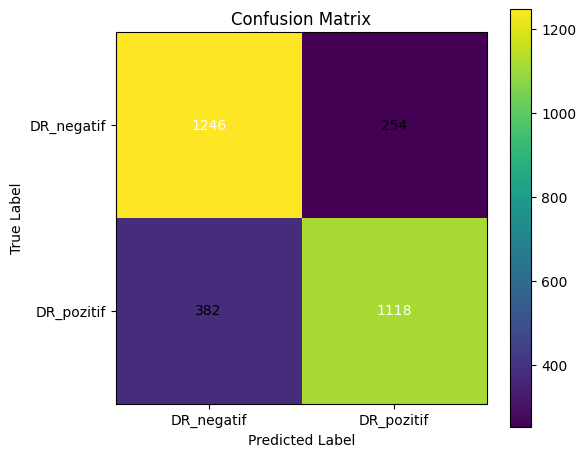

Confusion Matrix kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/Baseline_SVM_CM_20260121_230226.png


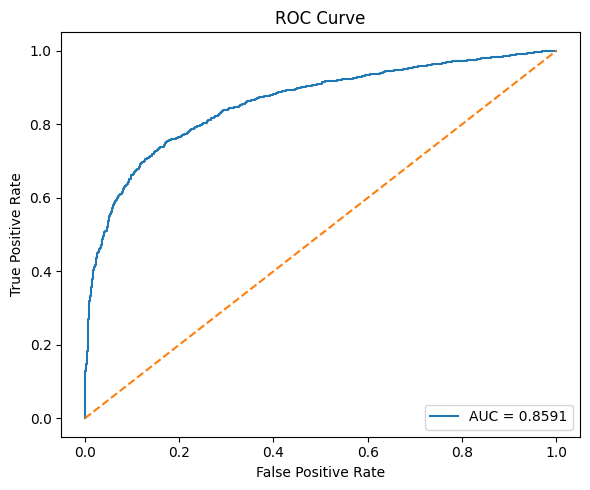

ROC Curve kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/Baseline_SVM_ROC_20260121_230226.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import numpy as np

# -------------------------
# BASELINE LinearSVC TEST
# -------------------------
svm_base = LinearSVC(C=1.0, random_state=42)
svm_base.fit(Xtr, y_train)

test_scores = svm_base.decision_function(Xte)
test_pred = (test_scores >= 0.0).astype(int)

print("\nBASELINE SVM (TEST)\n")
print(classification_report(y_test, test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("TEST AUC:", roc_auc_score(y_test, test_scores))
print("TEST Macro-F1:", f1_score(y_test, test_pred, average="macro"))


svm_cm = confusion_matrix(y_test, test_pred)
svm_cm_path = PLOT_DIR / f"Baseline_SVM_CM_{RUN_ID}.png"
save_confusion_matrix(svm_cm, ["DR_negatif", "DR_pozitif"], svm_cm_path)


roc_path = PLOT_DIR / f"Baseline_SVM_ROC_{RUN_ID}.png"
save_roc_curve(y_test, test_scores, roc_path)


BASELINE XGBoost (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7865    0.8593    0.8213      1500
  DR_pozitif     0.8450    0.7667    0.8039      1500

    accuracy                         0.8130      3000
   macro avg     0.8157    0.8130    0.8126      3000
weighted avg     0.8157    0.8130    0.8126      3000

Confusion Matrix:
 [[1289  211]
 [ 350 1150]]
TEST AUC: 0.8814764444444445
TEST Macro-F1: 0.8125976888829898


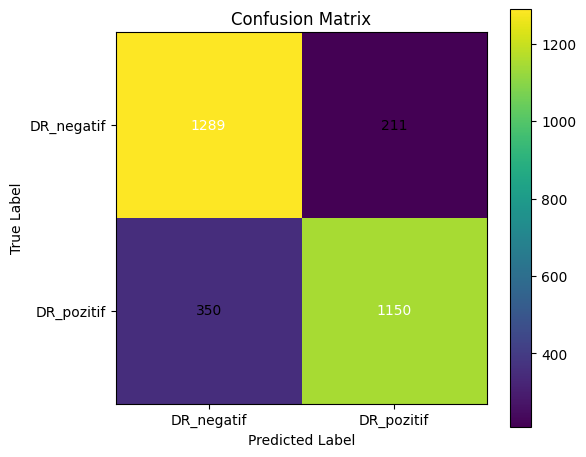

Confusion Matrix kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/Baseline_XGB_CM_20260121_230226.png


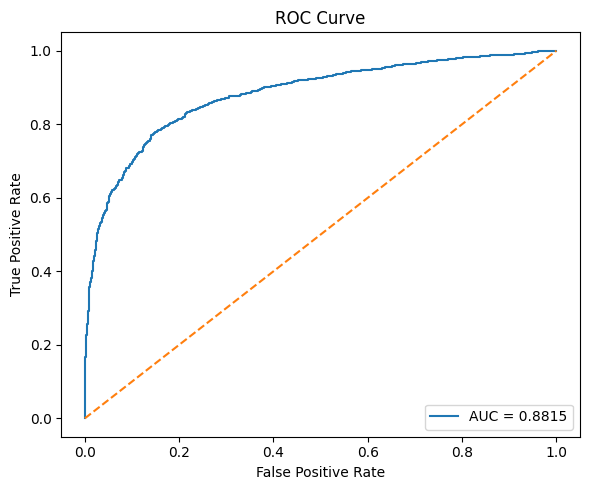

ROC Curve kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/Baseline_XGB_ROC_20260121_230226.png


In [ ]:
# -------------------------
# BASELINE XGBoost TEST
# -------------------------
xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)
xgb_base.fit(Xtr, y_train)

test_prob = xgb_base.predict_proba(Xte)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

print("\nBASELINE XGBoost (TEST)\n")
print(classification_report(y_test, test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("TEST AUC:", roc_auc_score(y_test, test_prob))
print("TEST Macro-F1:", f1_score(y_test, test_pred, average="macro"))

xgb_cm = confusion_matrix(y_test, test_pred)
cm_path = PLOT_DIR / f"Baseline_XGB_CM_{RUN_ID}.png"
save_confusion_matrix(xgb_cm, ["DR_negatif", "DR_pozitif"], cm_path)

roc_path = PLOT_DIR / f"Baseline_XGB_ROC_{RUN_ID}.png"
save_roc_curve(y_test, test_prob, roc_path)

**AŞAMA - 4: PSO ile Feature Selection (Binary Mask) (Hızlı Objective)**

In [ ]:
from sklearn.linear_model import LogisticRegression

def fitness_mask(mask, Xtr, ytr, Xva, yva, min_feats=80):
    idx = np.where(mask == 1)[0]
    if len(idx) < min_feats:
        return 0.0

    clf = LogisticRegression(max_iter=200, n_jobs=-1)
    clf.fit(Xtr[:, idx], ytr)
    prob = clf.predict_proba(Xva[:, idx])[:, 1]
    pred = (prob >= 0.5).astype(int)
    return f1_score(yva, pred, average="macro")

def binary_pso_feature_selection(Xtr, ytr, Xva, yva,
                                 n_particles=15, n_iters=15,
                                 w=0.72, c1=1.49, c2=1.49,
                                 min_feats=80, seed=42):
    rng = np.random.default_rng(seed)
    D = Xtr.shape[1]

    pos = rng.normal(0, 1, size=(n_particles, D))
    vel = rng.normal(0, 0.1, size=(n_particles, D))

    def binarize(p):
        s = 1 / (1 + np.exp(-p))
        return (s > rng.random(s.shape)).astype(np.int8)

    pbest_pos = pos.copy()
    pbest_fit = np.full(n_particles, -1e9, dtype=float)

    gbest_pos = None
    gbest_fit = -1e9

    cache = {}

    for it in range(n_iters):
        for i in range(n_particles):
            mask = binarize(pos[i])
            key = mask.tobytes()

            if key in cache:
                fit = cache[key]
            else:
                fit = fitness_mask(mask, Xtr, ytr, Xva, yva, min_feats=min_feats)
                cache[key] = fit

            if fit > pbest_fit[i]:
                pbest_fit[i] = fit
                pbest_pos[i] = pos[i].copy()

            if fit > gbest_fit:
                gbest_fit = fit
                gbest_pos = pos[i].copy()

        r1 = rng.random((n_particles, D))
        r2 = rng.random((n_particles, D))
        vel = w*vel + c1*r1*(pbest_pos - pos) + c2*r2*(gbest_pos - pos)
        pos = pos + vel

        print(f"Iter {it+1}/{n_iters} | Best Macro-F1: {gbest_fit:.4f}")

    best_mask = binarize(gbest_pos)
    return best_mask, gbest_fit

In [ ]:
best_mask, best_fit = binary_pso_feature_selection(
    Xtr, y_train, Xva, y_val,
    n_particles=15, n_iters=15,
    min_feats=80, seed=SEED
)

print("\nPSO bitti. Best VAL Macro-F1:", round(best_fit, 4))
print("Seçilen feature sayısı:", int(best_mask.sum()))

Iter 1/15 | Best Macro-F1: 0.8164
Iter 2/15 | Best Macro-F1: 0.8248
Iter 3/15 | Best Macro-F1: 0.8248
Iter 4/15 | Best Macro-F1: 0.8248
Iter 5/15 | Best Macro-F1: 0.8248
Iter 6/15 | Best Macro-F1: 0.8248
Iter 7/15 | Best Macro-F1: 0.8248
Iter 8/15 | Best Macro-F1: 0.8248
Iter 9/15 | Best Macro-F1: 0.8248
Iter 10/15 | Best Macro-F1: 0.8248
Iter 11/15 | Best Macro-F1: 0.8248
Iter 12/15 | Best Macro-F1: 0.8248
Iter 13/15 | Best Macro-F1: 0.8248
Iter 14/15 | Best Macro-F1: 0.8248
Iter 15/15 | Best Macro-F1: 0.8248

PSO bitti. Best VAL Macro-F1: 0.8248
Seçilen feature sayısı: 647


In [ ]:
best_mask

array([1, 1, 1, ..., 0, 0, 1], dtype=int8)

-> Seçilen feature’larla Test (SVM + XGBoost)

Seçilen feature: 647

SVM + PSO Feature Selection (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7691    0.8393    0.8027      1500
  DR_pozitif     0.8232    0.7480    0.7838      1500

    accuracy                         0.7937      3000
   macro avg     0.7961    0.7937    0.7932      3000
weighted avg     0.7961    0.7937    0.7932      3000

Confusion Matrix:
 [[1259  241]
 [ 378 1122]]
TEST AUC: 0.8585324444444445


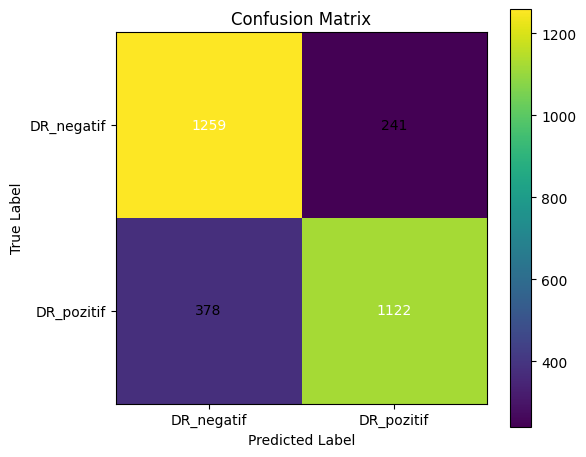

Confusion Matrix kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/PSO_FS_SVM_CM_20260121_234004.png


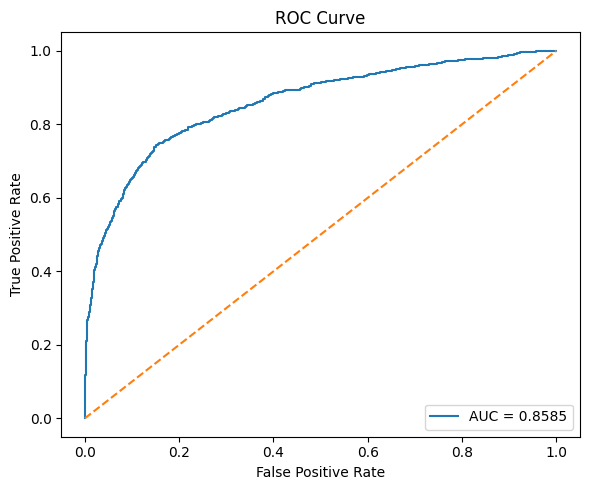

ROC Curve kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/PSO_FS_SVM_ROC_20260121_234004.png


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from datetime import datetime

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

idx = np.where(best_mask == 1)[0]
print("Seçilen feature:", len(idx))

# --- SVM (LinearSVC) ---
svm_fs = LinearSVC(C=1.0, random_state=SEED)
svm_fs.fit(Xtr[:, idx], y_train)

test_scores = svm_fs.decision_function(Xte[:, idx])
test_pred = (test_scores >= 0.0).astype(int)

print("\nSVM + PSO Feature Selection (TEST)\n")
print(classification_report(y_test, test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("TEST AUC:", roc_auc_score(y_test, test_scores))

svm_cm = confusion_matrix(y_test, test_pred)
svm_cm_path = PLOT_DIR / f"PSO_FS_SVM_CM_{RUN_ID}.png"
save_confusion_matrix(svm_cm, ["DR_negatif", "DR_pozitif"], svm_cm_path)

roc_path = PLOT_DIR / f"PSO_FS_SVM_ROC_{RUN_ID}.png"
save_roc_curve(y_test, test_scores, roc_path)


XGBoost + PSO Feature Selection (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7833    0.8507    0.8156      1500
  DR_pozitif     0.8366    0.7647    0.7990      1500

    accuracy                         0.8077      3000
   macro avg     0.8100    0.8077    0.8073      3000
weighted avg     0.8100    0.8077    0.8073      3000

Confusion Matrix:
 [[1276  224]
 [ 353 1147]]
TEST AUC: 0.8783688888888889


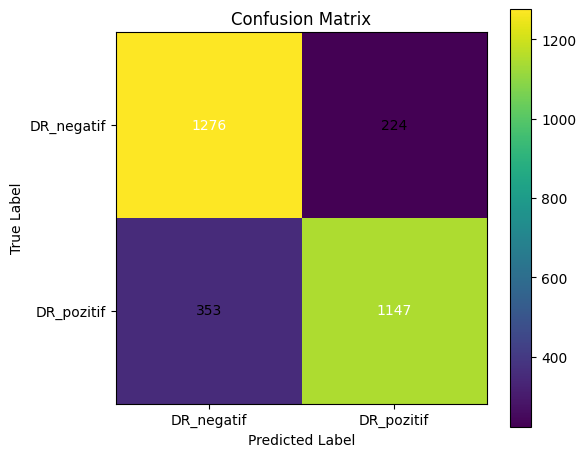

Confusion Matrix kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/PSO_FS_XGB_CM_20260121_234055.png


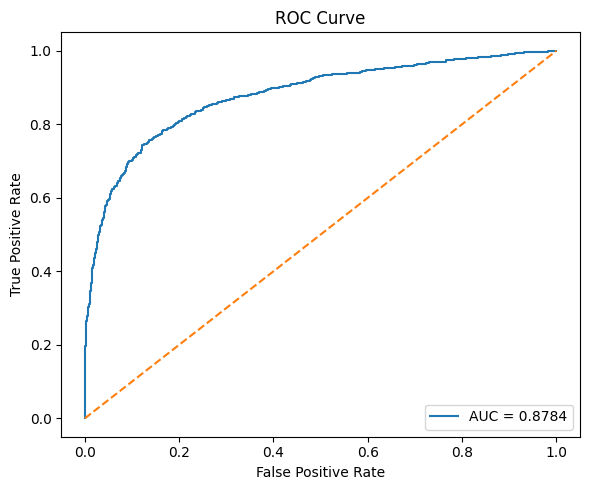

ROC Curve kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/PSO_FS_XGB_ROC_20260121_234055.png


In [ ]:
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

# --- XGBoost ---
xgb_fs = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)
xgb_fs.fit(Xtr[:, idx], y_train)

test_prob = xgb_fs.predict_proba(Xte[:, idx])[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

print("\nXGBoost + PSO Feature Selection (TEST)\n")
print(classification_report(y_test, test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("TEST AUC:", roc_auc_score(y_test, test_prob))

xgb_cm = confusion_matrix(y_test, test_pred)
cm_path = PLOT_DIR / f"PSO_FS_XGB_CM_{RUN_ID}.png"
save_confusion_matrix(xgb_cm, ["DR_negatif", "DR_pozitif"], cm_path)

roc_path = PLOT_DIR / f"PSO_FS_XGB_ROC_{RUN_ID}.png"
save_roc_curve(y_test, test_prob, roc_path)

**AŞAMA - 5: PSO XGBoost Hiperparametre Optimizasyonu + SO + Objective (Macro-F1 maximize) + Cache + EarlyStopping**

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

TUNE_FRAC = 0.50  # %50 train subset ile tuning (0.30 yaparsan daha da hızlanır)

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=(1 - TUNE_FRAC),
    random_state=SEED
)

idx_tune, _ = next(sss.split(Xtr, y_train))

Xtr_tune = Xtr[idx_tune]
ytr_tune = y_train[idx_tune]

print("Tuning subset hazır.")
print("Xtr_tune shape:", Xtr_tune.shape)
print("ytr_tune shape:", ytr_tune.shape)
print("Class dağılımı:", {c: int((ytr_tune==c).sum()) for c in np.unique(ytr_tune)})

Tuning subset hazır.
Xtr_tune shape: (7000, 1280)
ytr_tune shape: (7000,)
Class dağılımı: {np.int64(0): 3500, np.int64(1): 3500}


In [ ]:
import inspect
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
from collections import defaultdict

SEED = 42
rng = np.random.default_rng(SEED)

# -------------------------
# Yardımcı metrik fonksiyonu
# -------------------------
def macro_f1_auc(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    mf1 = f1_score(y_true, y_pred, average="macro")
    auc = roc_auc_score(y_true, y_prob)
    return mf1, auc

# -------------------------
# PSO (maximize)
# -------------------------
def pso_optimize(objective_fn, bounds, n_particles=10, n_iters=10,
                 w=0.72, c1=1.49, c2=1.49, seed=42, verbose=True):
    rng = np.random.default_rng(seed)
    D = len(bounds)

    low = np.array([b[0] for b in bounds], dtype=float)
    high = np.array([b[1] for b in bounds], dtype=float)

    # init
    pos = rng.uniform(low, high, size=(n_particles, D))
    vel = rng.normal(0, 0.1, size=(n_particles, D))

    pbest_pos = pos.copy()
    pbest_fit = np.full(n_particles, -1e9, dtype=float)

    gbest_pos = None
    gbest_fit = -1e9

    for it in range(n_iters):
        for i in range(n_particles):
            fit = objective_fn(pos[i])

            if fit > pbest_fit[i]:
                pbest_fit[i] = fit
                pbest_pos[i] = pos[i].copy()

            if fit > gbest_fit:
                gbest_fit = fit
                gbest_pos = pos[i].copy()

        # update
        r1 = rng.random((n_particles, D))
        r2 = rng.random((n_particles, D))

        vel = (w * vel
               + c1 * r1 * (pbest_pos - pos)
               + c2 * r2 * (gbest_pos - pos))

        pos = pos + vel
        pos = np.clip(pos, low, high)

        if verbose:
            print(f"Iter {it+1}/{n_iters} | Best Fitness (VAL Macro-F1): {gbest_fit:.6f}")

    return gbest_pos, gbest_fit

# -------------------------
# XGBoost PSO Objective (VAL Macro-F1)
# Cache: aynı parametreyi tekrar hesaplamasın
# Early stopping: hız kazanmak için
# -------------------------
xgb_cache = {}

def xgb_objective(vec):
    """
    vec = [n_estimators, max_depth, learning_rate, subsample, colsample_bytree]
    Fitness = VAL Macro-F1 (maximize)
    """

    # 1) PSO vektörünü 5 parametre olarak oku
    n_estimators = int(round(vec[0]))
    max_depth    = int(round(vec[1]))
    lr           = float(vec[2])
    subsample    = float(vec[3])
    colsample    = float(vec[4])

    # 2) Sabit bırakılan parametreler (optimizasyon DIŞI)
    min_child_weight = 1.0
    reg_lambda       = 1.0

    # 3) Cache key (5 parametre üzerinden)
    key = (
        n_estimators,
        max_depth,
        round(lr, 4),
        round(subsample, 3),
        round(colsample, 3),
    )
    if key in xgb_cache:
        return xgb_cache[key]["fitness"]

    # 4) XGBoost modeli (hızlı hist + early stopping)
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        subsample=subsample,
        colsample_bytree=colsample,

        # Sabit parametreler
        min_child_weight=min_child_weight,
        reg_lambda=reg_lambda,

        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist",
        early_stopping_rounds=20,   # hız için 20
    )

    # 5) XGBoost sürüm uyumluluğu
    fit_params = inspect.signature(model.fit).parameters
    if "early_stopping_rounds" in fit_params:
        model.fit(
            Xtr_tune, ytr_tune,        # SUBSET
            eval_set=[(Xva, y_val)],   # VAL aynı
            verbose=False,
            early_stopping_rounds=20
        )
    else:
        model.fit(
            Xtr_tune, ytr_tune,        # SUBSET
            eval_set=[(Xva, y_val)],   # VAL aynı
            verbose=False
        )

    # 6) VAL fitness (Macro-F1)
    val_prob = model.predict_proba(Xva)[:, 1]
    mf1, auc = macro_f1_auc(y_val, val_prob, thr=0.5)

    xgb_cache[key] = {
        "fitness": mf1,
        "mf1": mf1,
        "auc": auc,
        "best_iteration": getattr(model, "best_iteration", None)
    }

    return mf1

-> PSO ile XGBoost Hyperparameter Tuning

In [ ]:
xgb_bounds = [
    (200, 900),     # n_estimators
    (3, 7),         # max_depth
    (0.02, 0.15),   # learning_rate
    (0.7, 1.0),     # subsample
    (0.7, 1.0),     # colsample_bytree
]

best_vec, best_fit = pso_optimize(
    xgb_objective,
    bounds=xgb_bounds,
    n_particles=10,
    n_iters=10,
    seed=SEED,
    verbose=True
)

print("\nPSO bitti!")
print("Best VAL Macro-F1:", best_fit)
print("Best vector:", best_vec)

* Iter 1/10 | Best Fitness (VAL Macro-F1): 0.828410
* Iter 2/10 | Best Fitness (VAL Macro-F1): 0.828410
* Iter 3/10 | Best Fitness (VAL Macro-F1): 0.828410
* Iter 4/10 | Best Fitness (VAL Macro-F1): 0.828410
* Iter 5/10 | Best Fitness (VAL Macro-F1): 0.828410
* Iter 6/10 | Best Fitness (VAL Macro-F1): 0.828410
* Iter 7/10 | Best Fitness (VAL Macro-F1): 0.828410
* Iter 8/10 | Best Fitness (VAL Macro-F1): 0.830422
* Iter 9/10 | Best Fitness (VAL Macro-F1): 0.830422
* Iter 10/10 | Best Fitness (VAL Macro-F1): 0.830422

PSO bitti!

Best VAL Macro-F1: 0.8304217957397149

Best vector: [5.20434393e+02 5.79972475e+00 3.18957846e-02 7.54973082e-01
 9.15467644e-01]

In [ ]:
best_params = {
    "n_estimators": int(round(best_vec[0])),
    "max_depth": int(round(best_vec[1])),
    "learning_rate": float(best_vec[2]),
    "subsample": float(best_vec[3]),
    "colsample_bytree": float(best_vec[4]),

    # sabit kalanlar
    "min_child_weight": 1.0,
    "reg_lambda": 1.0
}

print("\nBest Params (decoded):")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Best Params (decoded):
  * n_estimators: 520
  * max_depth: 6
  * learning_rate: 0.0318957846360818
  * subsample: 0.7549730817455347
  * colsample_bytree: 0.9154676436661695
  * min_child_weight: 1.0
  * reg_lambda: 1.0

In [ ]:
best_params = {
    "n_estimators": 520,
    "max_depth": 6,
    "learning_rate": 0.0318957846360818,
    "subsample": 0.7549730817455347,
    "colsample_bytree": 0.9154676436661695,

    # sabit kalanlar
    "min_child_weight": 1.0,
    "reg_lambda": 1.0
}

print("\nBest Params (decoded):")
for k, v in best_params.items():
    print(f"  {k}: {v}")


Best Params (decoded):
  n_estimators: 520
  max_depth: 6
  learning_rate: 0.0318957846360818
  subsample: 0.7549730817455347
  colsample_bytree: 0.9154676436661695
  min_child_weight: 1.0
  reg_lambda: 1.0


In [ ]:
cache_key = (
    best_params["n_estimators"],
    best_params["max_depth"],
    round(best_params["learning_rate"], 4),
    round(best_params["subsample"], 3),
    round(best_params["colsample_bytree"], 3),
)

val_mf1 = xgb_cache[cache_key]["mf1"]
val_auc = xgb_cache[cache_key]["auc"]
best_it = xgb_cache[cache_key]["best_iteration"]

print("\nVAL metrics (PSO-tuned):")
print("Macro-F1:", round(val_mf1, 4))
print("AUC     :", round(val_auc, 4))
print("best_iteration:", best_it)

Best Params (decoded):
  * n_estimators: 520
  * max_depth: 6
  * learning_rate: 0.0318957846360818
  * subsample: 0.7549730817455347
  * colsample_bytree: 0.9154676436661695
  * min_child_weight: 1.0
  * reg_lambda: 1.0

VAL metrics (PSO-tuned):

Macro-F1: 0.8304

AUC     : 0.9047

best_iteration: 467

-> Final Model: Train+Val ile eğit → TEST raporu

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# train + val birleştir (final eğitim için)
X_final = np.vstack([Xtr, Xva])
y_final = np.concatenate([y_train, y_val])

# Eğer early stopping bir best_iteration verdiyse onu kullanmak daha stabil olur
if best_it is not None:
    final_n_estimators = int(best_it) + 1
else:
    final_n_estimators = best_params["n_estimators"]

print("\nFinal training n_estimators:", final_n_estimators)

final_model = XGBClassifier(
    n_estimators=final_n_estimators,
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    min_child_weight=best_params["min_child_weight"],
    reg_lambda=best_params["reg_lambda"],
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
)

final_model.fit(X_final, y_final)

# TEST değerlendirme
test_prob = final_model.predict_proba(Xte)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

test_mf1 = f1_score(y_test, test_pred, average="macro")
test_auc = roc_auc_score(y_test, test_prob)

print("\nPSO-TUNED XGBoost (TEST)\n")
print(classification_report(y_test, test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("TEST Macro-F1:", round(test_mf1, 4))
print("TEST AUC     :", round(test_auc, 4))

cm = confusion_matrix(y_test, test_pred)
cm_path = PLOT_DIR / f"CM_PSO_XGB_{RUN_ID}.png"
save_confusion_matrix(cm, ["DR_negatif", "DR_pozitif"], cm_path)

roc_path = PLOT_DIR / f"ROC_PSO_XGB_{RUN_ID}.png"
save_roc_curve(y_test, test_prob, roc_path)

Final training n_estimators: 468

PSO-TUNED XGBoost (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7857    0.8627    0.8224      1500
  DR_pozitif     0.8477    0.7647    0.8041      1500

    accuracy                         0.8137      3000
   macro avg     0.8167    0.8137    0.8132      3000
weighted avg     0.8167    0.8137    0.8132      3000

Confusion Matrix:
 [[1294  206]
 [ 353 1147]]
TEST Macro-F1: 0.8132
TEST AUC     : 0.8834


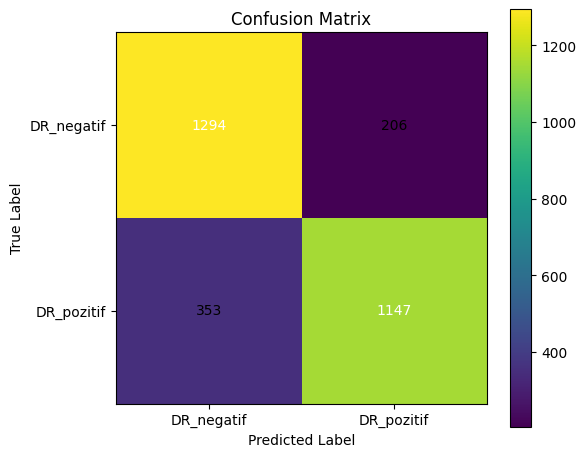

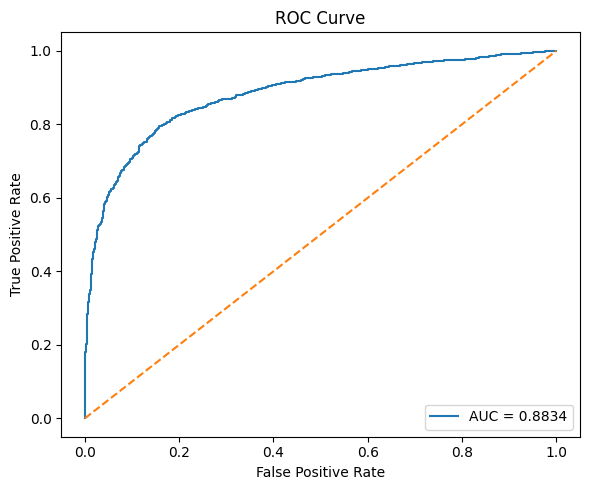

-> PSO SVM Hiperparametre Optimizasyonu

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)
Xva = scaler.transform(X_val)
Xte = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

TUNE_FRAC = 0.50  # %50 train ile PSO tuning (0.30 yaparsan daha da hızlı)

sss = StratifiedShuffleSplit(n_splits=1, test_size=(1 - TUNE_FRAC), random_state=SEED)
idx_tune, _ = next(sss.split(Xtr, y_train))

Xtr_tune = Xtr[idx_tune]
ytr_tune = y_train[idx_tune]

print("SVM tuning subset hazır:", Xtr_tune.shape)

SVM tuning subset hazır: (7000, 1280)


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, roc_auc_score

svm_cache = {}

def svm_objective_linear(vec):
    """
    vec = [log10_C]
    Fitness = VAL Macro-F1 (maximize)
    """
    logC = float(vec[0])
    C = 10 ** logC

    key = (round(logC, 4),)
    if key in svm_cache:
        return svm_cache[key]["fitness"]

    # LinearSVC için dual ayarı (performans)
    dual = True if (Xtr_tune.shape[0] < Xtr_tune.shape[1]) else False

    model = LinearSVC(
        C=C,
        dual=dual,
        max_iter=5000,
        random_state=SEED
    )

    # Subset ile fit (hız)
    model.fit(Xtr_tune, ytr_tune)

    # VAL tahmin
    val_pred = model.predict(Xva)

    # Fitness: Macro-F1
    mf1 = f1_score(y_val, val_pred, average="macro")

    # AUC: decision_function (probability şart değil)
    val_scores = model.decision_function(Xva)
    val_auc = roc_auc_score(y_val, val_scores)

    svm_cache[key] = {
        "fitness": mf1,
        "mf1": mf1,
        "auc": val_auc,
        "C": C
    }
    return mf1

In [ ]:
svm_bounds = [
    (-3.0, 3.0),   # log10(C)
]

best_vec_svm, best_fit_svm = pso_optimize(
    svm_objective_linear,
    bounds=svm_bounds,
    n_particles=12,
    n_iters=12,
    seed=SEED,
    verbose=True
)

best_logC = best_vec_svm[0]
best_C = 10 ** best_logC

print("\nPSO bitti (LinearSVC)!")
print("Best VAL Macro-F1:", best_fit_svm)
print("Best C:", best_C)

Iter 1/12 | Best Fitness (VAL Macro-F1): 0.805817
Iter 2/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 3/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 4/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 5/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 6/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 7/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 8/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 9/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 10/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 11/12 | Best Fitness (VAL Macro-F1): 0.815017
Iter 12/12 | Best Fitness (VAL Macro-F1): 0.815017

PSO bitti (LinearSVC)!
Best VAL Macro-F1: 0.8150173006683419
Best C: 0.001



PSO-TUNED LinearSVC (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7752    0.8573    0.8142      1500
  DR_pozitif     0.8404    0.7513    0.7934      1500

    accuracy                         0.8043      3000
   macro avg     0.8078    0.8043    0.8038      3000
weighted avg     0.8078    0.8043    0.8038      3000

Confusion Matrix:
 [[1286  214]
 [ 373 1127]]
TEST Macro-F1: 0.8038
TEST AUC     : 0.8757


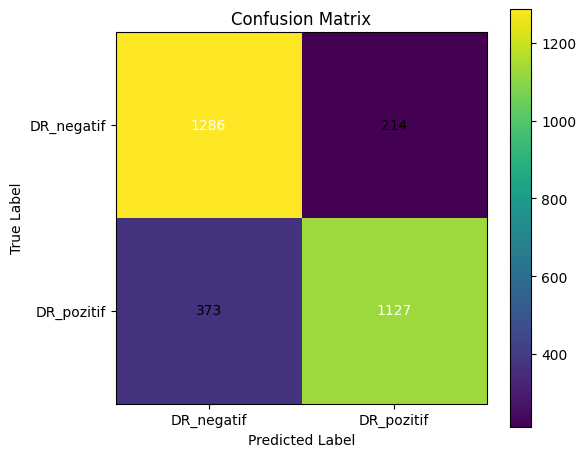

Confusion Matrix kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/SVM_PSO_OPT_CM_20260122_001354.png


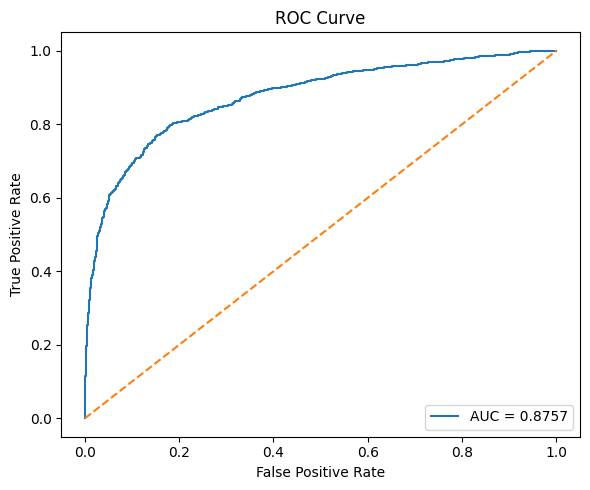

ROC Curve kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/SVM_PSO_OPT_ROC_20260122_001354.png


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score
from datetime import datetime

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
SEED = 42

# Train+Val birleşimi
X_final = np.vstack([Xtr, Xva])
y_final = np.concatenate([y_train, y_val])

dual = True if (X_final.shape[0] < X_final.shape[1]) else False

final_svm = LinearSVC(
    C=best_C,
    dual=dual,
    max_iter=5000,
    random_state=SEED
)

final_svm.fit(X_final, y_final)

# TEST tahmin
svm_test_pred = final_svm.predict(Xte)

# ROC/AUC için skor (LinearSVC'de probability yok)
svm_test_scores = final_svm.decision_function(Xte)

# metrikler
svm_test_mf1 = f1_score(y_test, svm_test_pred, average="macro")
svm_test_auc = roc_auc_score(y_test, svm_test_scores)
svm_cm = confusion_matrix(y_test, svm_test_pred)

print("\nPSO-TUNED LinearSVC (TEST)\n")
print(classification_report(y_test, svm_test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("Confusion Matrix:\n", svm_cm)
print("TEST Macro-F1:", round(svm_test_mf1, 4))
print("TEST AUC     :", round(svm_test_auc, 4))

cm_path = PLOT_DIR / f"SVM_PSO_OPT_CM_{RUN_ID}.png"
save_confusion_matrix(svm_cm, ["DR_negatif", "DR_pozitif"], cm_path)

roc_path = PLOT_DIR / f"SVM_PSO_OPT_ROC_{RUN_ID}.png"
save_roc_curve(y_test, svm_test_scores, roc_path)

**AŞAMA - 6: Feature Selection + (Hyperparameter Tuning)**

-> ABC

In [ ]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

SEED = 42
rng = np.random.default_rng(SEED)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

# Drive output
OUT_ROOT = Path("/content/drive/MyDrive/AUE_DR/Outputs")
PLOT_DIR = OUT_ROOT / "Plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_confusion_matrix(cm, labels, save_path, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=0)
    plt.yticks(tick_marks, labels)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("CM kaydedildi:", save_path)

def save_roc_curve(y_true, y_score, save_path, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("ROC kaydedildi:", save_path)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

TUNE_FRAC = 0.50  # %50 (0.30 daha hızlı)
sss = StratifiedShuffleSplit(n_splits=1, test_size=(1 - TUNE_FRAC), random_state=SEED)
idx_tune, _ = next(sss.split(Xtr, y_train))

Xtr_tune = Xtr[idx_tune]
ytr_tune = y_train[idx_tune]

print("ABC tuning subset:", Xtr_tune.shape)
print("Feature dim:", Xtr.shape[1])

ABC tuning subset: (7000, 1280)
Feature dim: 1280


In [ ]:
def abc_optimize(objective_fn, bounds, SN=10, max_cycles=10, limit=20, seed=42, verbose=True):
    """
    Artificial Bee Colony - MAXIMIZE
    SN: Food source sayısı (colony size = 2*SN)
    max_cycles: iterasyon
    limit: scout limit
    bounds: [(low, high), ...]
    """
    rng = np.random.default_rng(seed)
    D = len(bounds)

    low = np.array([b[0] for b in bounds], dtype=float)
    high = np.array([b[1] for b in bounds], dtype=float)

    # Food sources init
    X = rng.uniform(low, high, size=(SN, D))
    fit = np.array([objective_fn(x) for x in X], dtype=float)
    trial = np.zeros(SN, dtype=int)

    best_idx = int(np.argmax(fit))
    gbest = X[best_idx].copy()
    gbest_fit = fit[best_idx]

    def neighbor(i):
        """neighbor: v_ij = x_ij + phi*(x_ij - x_kj)"""
        k = rng.integers(0, SN)
        while k == i:
            k = rng.integers(0, SN)

        j = rng.integers(0, D)
        phi = rng.uniform(-1.0, 1.0)

        v = X[i].copy()
        v[j] = X[i, j] + phi * (X[i, j] - X[k, j])
        v = np.clip(v, low, high)
        return v

    for cyc in range(max_cycles):

        # ======================
        # 1) Employed Bees Phase
        # ======================
        for i in range(SN):
            v = neighbor(i)
            f_v = objective_fn(v)

            if f_v > fit[i]:
                X[i] = v
                fit[i] = f_v
                trial[i] = 0
            else:
                trial[i] += 1

        # ======================
        # 2) Onlooker Bees Phase
        # ======================
        # Probabilities (maximize)
        min_fit = fit.min()
        probs = (fit - min_fit + 1e-12)
        probs = probs / probs.sum()

        onlookers = 0
        while onlookers < SN:
            i = rng.choice(np.arange(SN), p=probs)
            v = neighbor(i)
            f_v = objective_fn(v)

            if f_v > fit[i]:
                X[i] = v
                fit[i] = f_v
                trial[i] = 0
            else:
                trial[i] += 1

            onlookers += 1

        # ======================
        # 3) Scout Phase
        # ======================
        for i in range(SN):
            if trial[i] >= limit:
                X[i] = rng.uniform(low, high, size=D)
                fit[i] = objective_fn(X[i])
                trial[i] = 0

        # Global best update
        best_idx = int(np.argmax(fit))
        if fit[best_idx] > gbest_fit:
            gbest_fit = fit[best_idx]
            gbest = X[best_idx].copy()

        if verbose:
            print(f"Cycle {cyc+1}/{max_cycles} | Best Fitness: {gbest_fit:.6f}")

    return gbest, gbest_fit

-> ABC ile Feature Selection (Binary Mask) - Fitness: VAL Macro-F1

In [ ]:
fs_cache = {}

def fs_objective_mask(vec, alpha=0.002, thr=0.5, min_feats=32):
    mask = (vec > thr)
    k = int(mask.sum())
    D = len(vec)

    if k < min_feats:
        return -1e9

    key = mask.tobytes()
    if key in fs_cache:
        return fs_cache[key]["fitness"]

    Xtr_m = Xtr_tune[:, mask]
    Xva_m = Xva[:, mask]

    dual = True if (Xtr_m.shape[0] < Xtr_m.shape[1]) else False
    clf = LinearSVC(C=1.0, dual=dual, max_iter=4000, random_state=SEED)
    clf.fit(Xtr_m, ytr_tune)

    val_pred = clf.predict(Xva_m)
    mf1 = f1_score(y_val, val_pred, average="macro")

    penalty = alpha * (k / D)
    fitness = mf1 - penalty

    fs_cache[key] = {"fitness": fitness, "mf1": mf1, "k": k}
    return fitness


D = Xtr.shape[1]
fs_bounds = [(0.0, 1.0)] * D

best_mask_vec, best_fit_fs = abc_optimize(
    lambda v: fs_objective_mask(v, alpha=0.002, thr=0.5, min_feats=32),
    bounds=fs_bounds,
    SN=10,             # hız için 8
    max_cycles=8,     # hız için 8-10
    limit=10,
    seed=SEED,
    verbose=True
)

best_mask = (best_mask_vec > 0.5)
selected_idx = np.where(best_mask)[0]

print("\nABC Feature Selection bitti!")
print("Best Fitness:", best_fit_fs)
print("Seçilen feature sayısı:", len(selected_idx), "/", D)

Cycle 1/8 | Best Fitness: 0.806591
Cycle 2/8 | Best Fitness: 0.806591
Cycle 3/8 | Best Fitness: 0.806593
Cycle 4/8 | Best Fitness: 0.806669
Cycle 5/8 | Best Fitness: 0.806669
Cycle 6/8 | Best Fitness: 0.806825
Cycle 7/8 | Best Fitness: 0.806825
Cycle 8/8 | Best Fitness: 0.806832

ABC Feature Selection bitti!
Best Fitness: 0.8068317646951533
Seçilen feature sayısı: 632 / 1280


In [ ]:
Xtr_fs = Xtr[:, best_mask]
Xva_fs = Xva[:, best_mask]
Xte_fs = Xte[:, best_mask]

print("Masked shapes:", Xtr_fs.shape, Xva_fs.shape, Xte_fs.shape)

Masked shapes: (14000, 632) (3000, 632) (3000, 632)


-> ABC ile SVM (LinearSVC) Hyperparam Tuning (Masked Feature’larda) - Optimize: C (log10 ölçekte)

In [ ]:
svm_cache = {}

def svm_objective_linear(vec):
    logC = float(vec[0])
    C = 10 ** logC

    key = (round(logC, 4),)
    if key in svm_cache:
        return svm_cache[key]["fitness"]

    dual = True if (Xtr_fs.shape[0] < Xtr_fs.shape[1]) else False
    clf = LinearSVC(C=C, dual=dual, max_iter=4000, random_state=SEED)
    clf.fit(Xtr_fs[idx_tune], y_train[idx_tune])

    val_pred = clf.predict(Xva_fs)
    mf1 = f1_score(y_val, val_pred, average="macro")

    svm_cache[key] = {"fitness": mf1, "C": C}
    return mf1


svm_bounds = [(-3.0, 3.0)]  # log10(C)

best_vec_svm, best_fit_svm = abc_optimize(
    svm_objective_linear,
    bounds=svm_bounds,
    SN=10,
    max_cycles=10,
    limit=15,
    seed=SEED,
    verbose=True
)

best_C = 10 ** float(best_vec_svm[0])
print("\nABC-Tuned SVM Best VAL Macro-F1:", best_fit_svm)
print("Best C:", best_C)

Cycle 1/10 | Best Fitness: 0.813979
Cycle 2/10 | Best Fitness: 0.813979
Cycle 3/10 | Best Fitness: 0.813979
Cycle 4/10 | Best Fitness: 0.813979
Cycle 5/10 | Best Fitness: 0.813979
Cycle 6/10 | Best Fitness: 0.813979
Cycle 7/10 | Best Fitness: 0.813979
Cycle 8/10 | Best Fitness: 0.813979
Cycle 9/10 | Best Fitness: 0.813979
Cycle 10/10 | Best Fitness: 0.813979

ABC-Tuned SVM Best VAL Macro-F1: 0.8139786319224913
Best C: 0.001



FS + ABC-TUNED LinearSVC (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7674    0.8667    0.8140      1500
  DR_pozitif     0.8469    0.7373    0.7883      1500

    accuracy                         0.8020      3000
   macro avg     0.8071    0.8020    0.8012      3000
weighted avg     0.8071    0.8020    0.8012      3000

TEST Macro-F1: 0.8012
TEST AUC     : 0.8738


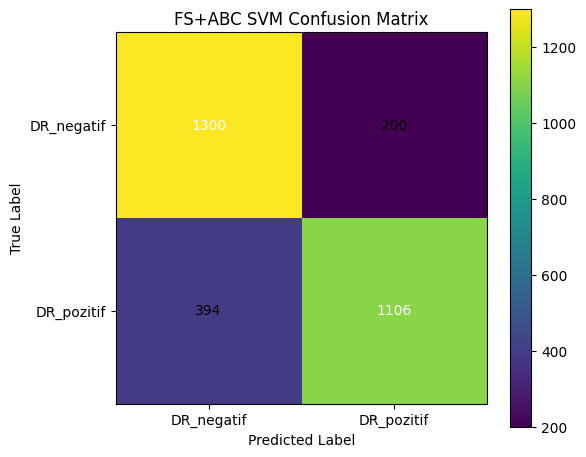

CM kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/SVM_FS_ABC_OPT_CM_20260122_003501.png


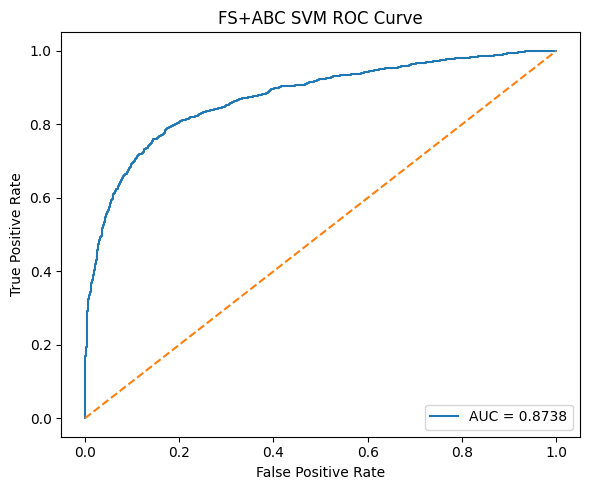

ROC kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/SVM_FS_ABC_OPT_ROC_20260122_003501.png


In [ ]:
X_final_svm = np.vstack([Xtr_fs, Xva_fs])
y_final_svm = np.concatenate([y_train, y_val])

dual = True if (X_final_svm.shape[0] < X_final_svm.shape[1]) else False
final_svm = LinearSVC(C=best_C, dual=dual, max_iter=4000, random_state=SEED)
final_svm.fit(X_final_svm, y_final_svm)

svm_test_pred = final_svm.predict(Xte_fs)
svm_test_scores = final_svm.decision_function(Xte_fs)

svm_test_mf1 = f1_score(y_test, svm_test_pred, average="macro")
svm_test_auc = roc_auc_score(y_test, svm_test_scores)
svm_cm = confusion_matrix(y_test, svm_test_pred)

print("\nFS + ABC-TUNED LinearSVC (TEST)\n")
print(classification_report(y_test, svm_test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("TEST Macro-F1:", round(svm_test_mf1, 4))
print("TEST AUC     :", round(svm_test_auc, 4))

cm_path = PLOT_DIR / f"SVM_FS_ABC_OPT_CM_{RUN_ID}.png"
roc_path = PLOT_DIR / f"SVM_FS_ABC_OPT_ROC_{RUN_ID}.png"
save_confusion_matrix(svm_cm, ["DR_negatif","DR_pozitif"], cm_path, title="FS+ABC SVM Confusion Matrix")

save_roc_curve(y_test, svm_test_scores, roc_path, title="FS+ABC SVM ROC Curve")

-> ABC ile XGBoost Hyperparam Tuning (Masked Feature’larda)

In [ ]:
USE_GPU_XGB = False
try:
    _ = XGBClassifier(tree_method="gpu_hist", n_estimators=10)
    USE_GPU_XGB = True
    print("XGBoost GPU aktif: gpu_hist kullanılacak.")
except:
    print("ℹGPU bulunamadı / gpu_hist yok. hist kullanılacak.")

TREE_METHOD = "gpu_hist" if USE_GPU_XGB else "hist"
PREDICTOR = "gpu_predictor" if USE_GPU_XGB else "auto"

In [ ]:
xgb_cache = {}

def xgb_objective(vec):
    n_estimators = int(round(vec[0]))
    max_depth    = int(round(vec[1]))
    lr           = float(vec[2])
    subsample    = float(vec[3])
    colsample    = float(vec[4])

    key = (
        n_estimators,
        max_depth,
        round(lr, 4),
        round(subsample, 3),
        round(colsample, 3),
    )
    if key in xgb_cache:
        return xgb_cache[key]["fitness"]

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        subsample=subsample,
        colsample_bytree=colsample,
        min_child_weight=1.0,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
        tree_method=TREE_METHOD,
        predictor=PREDICTOR,
        early_stopping_rounds=20
    )

    fit_params = inspect.signature(model.fit).parameters

    if "early_stopping_rounds" in fit_params:
        model.fit(
            Xtr_fs[idx_tune], y_train[idx_tune],
            eval_set=[(Xva_fs, y_val)],
            verbose=False,
            early_stopping_rounds=20
        )
    else:
        model.fit(
            Xtr_fs[idx_tune], y_train[idx_tune],
            eval_set=[(Xva_fs, y_val)],
            verbose=False
        )

    val_prob = model.predict_proba(Xva_fs)[:, 1]
    val_pred = (val_prob >= 0.5).astype(int)
    mf1 = f1_score(y_val, val_pred, average="macro")

    xgb_cache[key] = {
        "fitness": mf1,
        "best_iteration": getattr(model, "best_iteration", None)
    }
    return mf1

In [ ]:
xgb_bounds = [
    (200, 800),     # n_estimators
    (3, 7),         # max_depth
    (0.02, 0.12),   # learning_rate
    (0.7, 1.0),     # subsample
    (0.7, 1.0),     # colsample_bytree
]

best_vec_xgb, best_fit_xgb = abc_optimize(
    xgb_objective,
    bounds=xgb_bounds,
    SN=10,
    max_cycles=10,
    limit=15,
    seed=SEED,
    verbose=True
)

best_params = {
    "n_estimators": int(round(best_vec_xgb[0])),
    "max_depth": int(round(best_vec_xgb[1])),
    "learning_rate": float(best_vec_xgb[2]),
    "subsample": float(best_vec_xgb[3]),
    "colsample_bytree": float(best_vec_xgb[4]),
    "min_child_weight": 1.0,
    "reg_lambda": 1.0
}

print("\nABC-Tuned XGB Best VAL Macro-F1:", best_fit_xgb)
print("Best params:", best_params)

In [ ]:
cache_key = (
    best_params["n_estimators"],
    best_params["max_depth"],
    round(best_params["learning_rate"], 4),
    round(best_params["subsample"], 3),
    round(best_params["colsample_bytree"], 3),
)

best_it = xgb_cache[cache_key]["best_iteration"]
final_n_estimators = (int(best_it) + 1) if best_it is not None else best_params["n_estimators"]
print("Final n_estimators:", final_n_estimators)

In [ ]:
X_final_xgb = np.vstack([Xtr_fs, Xva_fs])
y_final_xgb = np.concatenate([y_train, y_val])

final_xgb = XGBClassifier(
    n_estimators=final_n_estimators,
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    min_child_weight=best_params["min_child_weight"],
    reg_lambda=best_params["reg_lambda"],
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
    tree_method=TREE_METHOD,
    predictor=PREDICTOR,
)

final_xgb.fit(X_final_xgb, y_final_xgb)

xgb_test_prob = final_xgb.predict_proba(Xte_fs)[:, 1]
xgb_test_pred = (xgb_test_prob >= 0.5).astype(int)

xgb_test_mf1 = f1_score(y_test, xgb_test_pred, average="macro")
xgb_test_auc = roc_auc_score(y_test, xgb_test_prob)
xgb_cm = confusion_matrix(y_test, xgb_test_pred)

print("\nFS + ABC-TUNED XGBoost (TEST)\n")
print(classification_report(y_test, xgb_test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("TEST Macro-F1:", round(xgb_test_mf1, 4))
print("TEST AUC     :", round(xgb_test_auc, 4))

cm_path = PLOT_DIR / f"CM_FS_ABC_XGB_{RUN_ID}.png"
roc_path = PLOT_DIR / f"ROC_FS_ABC_XGB_{RUN_ID}.png"
save_confusion_matrix(xgb_cm, ["DR_negatif","DR_pozitif"], cm_path, title="FS+ABC XGB Confusion Matrix")
save_roc_curve(y_test, xgb_test_prob, roc_path, title="FS+ABC XGB ROC Curve")

In [ ]:
print("\n================= FINAL SUMMARY (ABC) =================")
print(f"Selected features: {len(selected_idx)}/{D}")
print("\nFS + ABC SVM -> TEST Macro-F1:", round(svm_test_mf1,4), "| AUC:", round(svm_test_auc,4))
print("FS + ABC XGB -> TEST Macro-F1:", round(xgb_test_mf1,4), "| AUC:", round(xgb_test_auc,4))

-> PSO

In [ ]:
def pso_optimize(objective_fn, bounds, n_particles=10, n_iters=10,
                 w=0.72, c1=1.49, c2=1.49, seed=42, verbose=True):
    rng = np.random.default_rng(seed)
    D = len(bounds)

    low = np.array([b[0] for b in bounds], dtype=float)
    high = np.array([b[1] for b in bounds], dtype=float)

    pos = rng.uniform(low, high, size=(n_particles, D))
    vel = rng.normal(0, 0.1, size=(n_particles, D))

    pbest_pos = pos.copy()
    pbest_fit = np.full(n_particles, -1e9, dtype=float)

    gbest_pos = None
    gbest_fit = -1e9

    for it in range(n_iters):
        for i in range(n_particles):
            fit = objective_fn(pos[i])

            if fit > pbest_fit[i]:
                pbest_fit[i] = fit
                pbest_pos[i] = pos[i].copy()

            if fit > gbest_fit:
                gbest_fit = fit
                gbest_pos = pos[i].copy()

        r1 = rng.random((n_particles, D))
        r2 = rng.random((n_particles, D))
        vel = (w * vel + c1 * r1 * (pbest_pos - pos) + c2 * r2 * (gbest_pos - pos))
        pos = pos + vel
        pos = np.clip(pos, low, high)

        if verbose:
            print(f"Iter {it+1}/{n_iters} | Best Fitness: {gbest_fit:.6f}")

    return gbest_pos, gbest_fit


# -------------------------
# Subset (PSO objective hızlandırma)
# -------------------------
from sklearn.model_selection import StratifiedShuffleSplit

TUNE_FRAC = 0.50   # %50 (0.30 daha hızlı)
sss = StratifiedShuffleSplit(n_splits=1, test_size=(1 - TUNE_FRAC), random_state=SEED)
idx_tune, _ = next(sss.split(Xtr, y_train))

Xtr_tune = Xtr[idx_tune]
ytr_tune = y_train[idx_tune]

print("Tuning subset:", Xtr_tune.shape)
print("Feature dim   :", Xtr.shape[1])

Tuning subset: (7000, 1280)
Feature dim   : 1280


In [ ]:
fs_cache = {}

def fs_objective_mask(vec, alpha=0.002, thr=0.5, min_feats=32):
    """
    vec: continuous [0..1] (PSO pozisyonu)
    mask = vec > thr
    Fitness = VAL Macro-F1 - alpha*(selected_ratio)
    """
    mask = (vec > thr)
    k = int(mask.sum())
    D = len(vec)

    # çok az feature seçerse cezalandır
    if k < min_feats:
        return -1e9

    # cache key: mask bytes
    key = mask.tobytes()
    if key in fs_cache:
        return fs_cache[key]["fitness"]

    # subset ile fit (hız)
    Xtr_m = Xtr_tune[:, mask]
    Xva_m = Xva[:, mask]

    dual = True if (Xtr_m.shape[0] < Xtr_m.shape[1]) else False
    clf = LinearSVC(C=1.0, dual=dual, max_iter=4000, random_state=SEED)
    clf.fit(Xtr_m, ytr_tune)

    val_pred = clf.predict(Xva_m)
    mf1 = f1_score(y_val, val_pred, average="macro")

    # sparsity penalty
    penalty = alpha * (k / D)
    fitness = mf1 - penalty

    fs_cache[key] = {
        "fitness": fitness,
        "mf1": mf1,
        "k": k
    }
    return fitness

In [ ]:
# -------------------------
# PSO Feature Selection bounds
# -------------------------
D = Xtr.shape[1]
fs_bounds = [(0.0, 1.0)] * D

best_mask_vec, best_fit_fs = pso_optimize(
    lambda v: fs_objective_mask(v, alpha=0.002, thr=0.5, min_feats=32),
    bounds=fs_bounds,
    n_particles=10,
    n_iters=10,
    seed=SEED,
    verbose=True
)

best_mask = (best_mask_vec > 0.5)
selected_idx = np.where(best_mask)[0]

print("\nPSO Feature Selection bitti!")
print("Best Fitness:", best_fit_fs)
print("Seçilen feature sayısı:", len(selected_idx), "/", D)

Iter 1/10 | Best Fitness: 0.806591
Iter 2/10 | Best Fitness: 0.806591
Iter 3/10 | Best Fitness: 0.808245
Iter 4/10 | Best Fitness: 0.813223
Iter 5/10 | Best Fitness: 0.813223
Iter 6/10 | Best Fitness: 0.813603
Iter 7/10 | Best Fitness: 0.813603
Iter 8/10 | Best Fitness: 0.813603
Iter 9/10 | Best Fitness: 0.813603
Iter 10/10 | Best Fitness: 0.813603

PSO Feature Selection bitti!
Best Fitness: 0.8136030985482933
Seçilen feature sayısı: 592 / 1280


In [ ]:
Xtr_fs = Xtr[:, best_mask]
Xva_fs = Xva[:, best_mask]
Xte_fs = Xte[:, best_mask]

print("Masked shapes:")
print("Train:", Xtr_fs.shape, "Val:", Xva_fs.shape, "Test:", Xte_fs.shape)

Masked shapes:
Train: (14000, 592) Val: (3000, 592) Test: (3000, 592)


-> PSO - SVM Hiperparametre Optimizasyonu

In [ ]:
svm_cache = {}

def svm_objective_linear(vec):
    """
    vec = [log10(C)]
    Fitness = VAL Macro-F1
    """
    logC = float(vec[0])
    C = 10 ** logC

    key = (round(logC, 4),)
    if key in svm_cache:
        return svm_cache[key]["fitness"]

    dual = True if (Xtr_fs.shape[0] < Xtr_fs.shape[1]) else False

    clf = LinearSVC(C=C, dual=dual, max_iter=4000, random_state=SEED)
    clf.fit(Xtr_fs[idx_tune], y_train[idx_tune])  # subset

    val_pred = clf.predict(Xva_fs)
    mf1 = f1_score(y_val, val_pred, average="macro")

    svm_cache[key] = {"fitness": mf1, "C": C}
    return mf1


svm_bounds = [(-3.0, 3.0)]  # log10(C)

best_vec_svm, best_fit_svm = pso_optimize(
    svm_objective_linear,
    bounds=svm_bounds,
    n_particles=10,
    n_iters=10,
    seed=SEED,
    verbose=True
)

best_C = 10 ** float(best_vec_svm[0])
print("\nPSO-Tuned SVM Best VAL Macro-F1:", best_fit_svm)
print("Best C:", best_C)

Iter 1/10 | Best Fitness: 0.817122
Iter 2/10 | Best Fitness: 0.817379
Iter 3/10 | Best Fitness: 0.818376
Iter 4/10 | Best Fitness: 0.818376
Iter 5/10 | Best Fitness: 0.818376
Iter 6/10 | Best Fitness: 0.818376
Iter 7/10 | Best Fitness: 0.818376
Iter 8/10 | Best Fitness: 0.818376
Iter 9/10 | Best Fitness: 0.818376
Iter 10/10 | Best Fitness: 0.818376

PSO-Tuned SVM Best VAL Macro-F1: 0.8183760683760684
Best C: 0.0013876621209285463



FS + PSO-TUNED LinearSVC (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7696    0.8620    0.8132      1500
  DR_pozitif     0.8432    0.7420    0.7894      1500

    accuracy                         0.8020      3000
   macro avg     0.8064    0.8020    0.8013      3000
weighted avg     0.8064    0.8020    0.8013      3000

TEST Macro-F1: 0.8013
TEST AUC     : 0.8758
CM:
 [[1293  207]
 [ 387 1113]]


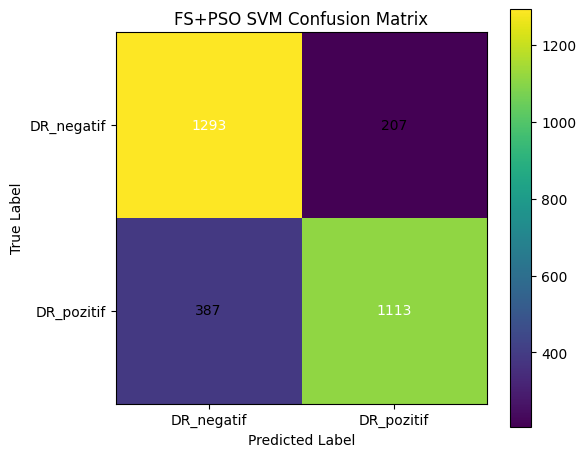

CM kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/SVM_FS_PSO_OPT_CM_20260122_003501.png


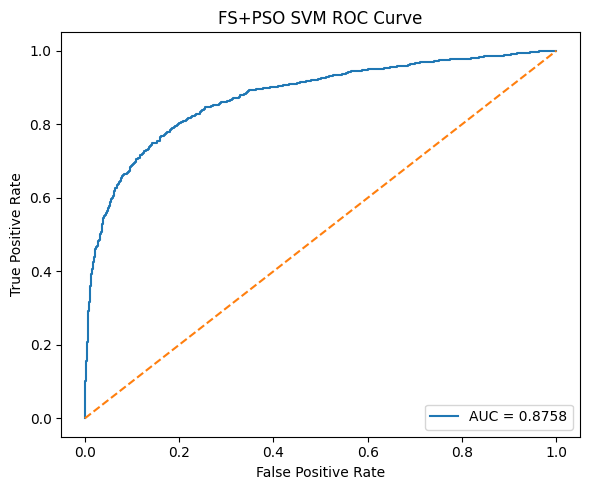

ROC kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/SVM_FS_PSO_OPT_ROC_20260122_003501.png


In [ ]:
# Final training (Train+Val)
X_final_svm = np.vstack([Xtr_fs, Xva_fs])
y_final_svm = np.concatenate([y_train, y_val])

dual = True if (X_final_svm.shape[0] < X_final_svm.shape[1]) else False
final_svm = LinearSVC(C=best_C, dual=dual, max_iter=4000, random_state=SEED)
final_svm.fit(X_final_svm, y_final_svm)

svm_test_pred = final_svm.predict(Xte_fs)
svm_test_scores = final_svm.decision_function(Xte_fs)

svm_test_mf1 = f1_score(y_test, svm_test_pred, average="macro")
svm_test_auc = roc_auc_score(y_test, svm_test_scores)
svm_cm = confusion_matrix(y_test, svm_test_pred)

print("\nFS + PSO-TUNED LinearSVC (TEST)\n")
print(classification_report(y_test, svm_test_pred, target_names=["DR_negatif","DR_pozitif"], digits=4))
print("TEST Macro-F1:", round(svm_test_mf1, 4))
print("TEST AUC     :", round(svm_test_auc, 4))
print("CM:\n", svm_cm)

cm_path = PLOT_DIR / f"SVM_FS_PSO_OPT_CM_{RUN_ID}.png"
roc_path = PLOT_DIR / f"SVM_FS_PSO_OPT_ROC_{RUN_ID}.png"
save_confusion_matrix(svm_cm, ["DR_negatif","DR_pozitif"], cm_path, title="FS+PSO SVM Confusion Matrix")

save_roc_curve(y_test, svm_test_scores, roc_path, title="FS+PSO SVM ROC Curve")

-> PSO ile XGBoost Hyperparam Tuning (Masked Feature’larda)

In [ ]:
import inspect
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

# =========================
# 0) CONFIG
# =========================
SEED = 42
rng = np.random.default_rng(SEED)

TREE_METHOD = "hist"
EARLY_STOP = 20

# =========================
# 1) METRICS
# =========================
def macro_f1_auc(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    mf1 = f1_score(y_true, y_pred, average="macro")
    auc = roc_auc_score(y_true, y_prob)
    return mf1, auc

# =========================
# 2) PSO OPTIMIZER (maximize)
# =========================
def pso_optimize(objective_fn, bounds, n_particles=10, n_iters=10,
                 w=0.72, c1=1.49, c2=1.49, seed=42, verbose=True):
    rng = np.random.default_rng(seed)
    D = len(bounds)

    low = np.array([b[0] for b in bounds], dtype=float)
    high = np.array([b[1] for b in bounds], dtype=float)

    # init
    pos = rng.uniform(low, high, size=(n_particles, D))
    vel = rng.normal(0, 0.1, size=(n_particles, D))

    pbest_pos = pos.copy()
    pbest_fit = np.full(n_particles, -1e9, dtype=float)

    gbest_pos = None
    gbest_fit = -1e9

    for it in range(n_iters):
        for i in range(n_particles):
            fit = objective_fn(pos[i])

            if fit > pbest_fit[i]:
                pbest_fit[i] = fit
                pbest_pos[i] = pos[i].copy()

            if fit > gbest_fit:
                gbest_fit = fit
                gbest_pos = pos[i].copy()

        # update
        r1 = rng.random((n_particles, D))
        r2 = rng.random((n_particles, D))

        vel = (w * vel
               + c1 * r1 * (pbest_pos - pos)
               + c2 * r2 * (gbest_pos - pos))

        pos = pos + vel
        pos = np.clip(pos, low, high)

        if verbose:
            print(f"Iter {it+1}/{n_iters} | Best Fitness (VAL Macro-F1): {gbest_fit:.6f}")

    return gbest_pos, gbest_fit


In [ ]:
USE_TUNE_SUBSET = True
TUNE_FRAC = 0.35  # %35 train ile PSO (çok hızlanır)

if USE_TUNE_SUBSET:
    n = Xtr_fs.shape[0]
    k = int(n * TUNE_FRAC)
    idx = rng.choice(n, size=k, replace=False)

    Xtr_tune = Xtr_fs[idx]
    ytr_tune = y_train[idx]

    print(f"Tuning subset aktif: {k}/{n} örnek (%.0f%%)" % (100*TUNE_FRAC))
else:
    Xtr_tune = Xtr_fs
    ytr_tune = y_train
    print("Tuning subset kapalı: tüm train kullanılacak")

# =========================
# 4) XGB OBJECTIVE (VAL Macro-F1 maximize)
# =========================
xgb_cache = {}

def xgb_objective(vec):
    """
    vec = [n_estimators, max_depth, learning_rate, subsample, colsample_bytree]
    Fitness = VAL Macro-F1 (maximize)
    """

    # ---- decode params
    n_estimators = int(round(vec[0]))
    max_depth    = int(round(vec[1]))
    lr           = float(vec[2])
    subsample    = float(vec[3])
    colsample    = float(vec[4])

    # ---- cache key
    key = (
        n_estimators,
        max_depth,
        round(lr, 5),
        round(subsample, 4),
        round(colsample, 4)
    )
    if key in xgb_cache:
        return xgb_cache[key]["fitness"]

    # ---- model
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=lr,
        subsample=subsample,
        colsample_bytree=colsample,

        # sabit bırakılanlar (istersen bounds'a ekleyebiliriz)
        min_child_weight=1.0,
        reg_lambda=1.0,

        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
        tree_method=TREE_METHOD,
    )

    # ---- early stopping sürüm uyumluluğu
    fit_params = inspect.signature(model.fit).parameters
    if "early_stopping_rounds" in fit_params:
        model.fit(
            Xtr_tune, ytr_tune,
            eval_set=[(Xva_fs, y_val)],
            verbose=False,
            early_stopping_rounds=EARLY_STOP
        )
        best_it = getattr(model, "best_iteration", None)
    else:
        # bazı sürümlerde early stopping yoksa
        model.fit(
            Xtr_tune, ytr_tune,
            eval_set=[(Xva_fs, y_val)],
            verbose=False
        )
        best_it = None

    # ---- VAL fitness
    val_prob = model.predict_proba(Xva_fs)[:, 1]
    mf1, auc = macro_f1_auc(y_val, val_prob, thr=0.5)

    xgb_cache[key] = {
        "fitness": mf1,
        "auc": auc,
        "best_iteration": best_it
    }
    return mf1

Tuning subset aktif: 4900/14000 örnek (35%)


In [ ]:
# =========================
# 5) PSO BOUNDS
# =========================
xgb_bounds = [
    (200, 800),     # n_estimators
    (3, 7),         # max_depth
    (0.02, 0.12),   # learning_rate
    (0.7, 1.0),     # subsample
    (0.7, 1.0),     # colsample_bytree
]

# =========================
# 6) RUN PSO
# =========================
best_vec_xgb, best_fit_xgb = pso_optimize(
    xgb_objective,
    bounds=xgb_bounds,
    n_particles=10,
    n_iters=10,
    seed=SEED,
    verbose=True
)

best_params = {
    "n_estimators": int(round(best_vec_xgb[0])),
    "max_depth": int(round(best_vec_xgb[1])),
    "learning_rate": float(best_vec_xgb[2]),
    "subsample": float(best_vec_xgb[3]),
    "colsample_bytree": float(best_vec_xgb[4]),
    "min_child_weight": 1.0,
    "reg_lambda": 1.0
}

print("\nPSO-Tuned XGB Best VAL Macro-F1:", best_fit_xgb)
print("Best params:", best_params)

Iter 1/10 | Best Fitness (VAL Macro-F1): 0.813187
Iter 2/10 | Best Fitness (VAL Macro-F1): 0.815432
Iter 3/10 | Best Fitness (VAL Macro-F1): 0.815432
Iter 4/10 | Best Fitness (VAL Macro-F1): 0.817798
Iter 5/10 | Best Fitness (VAL Macro-F1): 0.817798
Iter 6/10 | Best Fitness (VAL Macro-F1): 0.817798
Iter 7/10 | Best Fitness (VAL Macro-F1): 0.817798
Iter 8/10 | Best Fitness (VAL Macro-F1): 0.817798
Iter 9/10 | Best Fitness (VAL Macro-F1): 0.822851
Iter 10/10 | Best Fitness (VAL Macro-F1): 0.822851

PSO-Tuned XGB Best VAL Macro-F1: 0.8228510177058906
Best params: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.12, 'subsample': 0.8474808543196777, 'colsample_bytree': 0.7, 'min_child_weight': 1.0, 'reg_lambda': 1.0}



Final training n_estimators (bounds): 800

PSO-TUNED XGBoost (TEST)

              precision    recall  f1-score   support

  DR_negatif     0.7753    0.8647    0.8175      1500
  DR_pozitif     0.8470    0.7493    0.7952      1500

    accuracy                         0.8070      3000
   macro avg     0.8111    0.8070    0.8064      3000
weighted avg     0.8111    0.8070    0.8064      3000

TEST Macro-F1: 0.8064
TEST AUC     : 0.878
CM:
 [[1297  203]
 [ 376 1124]]


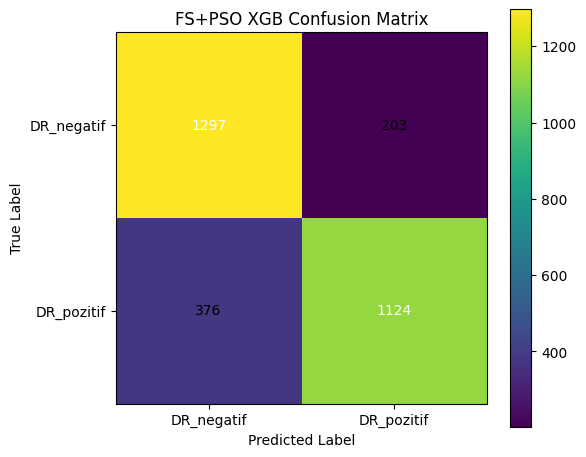

CM kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/XGB_FS_PSO_OPT_CM_20260122_003501.png


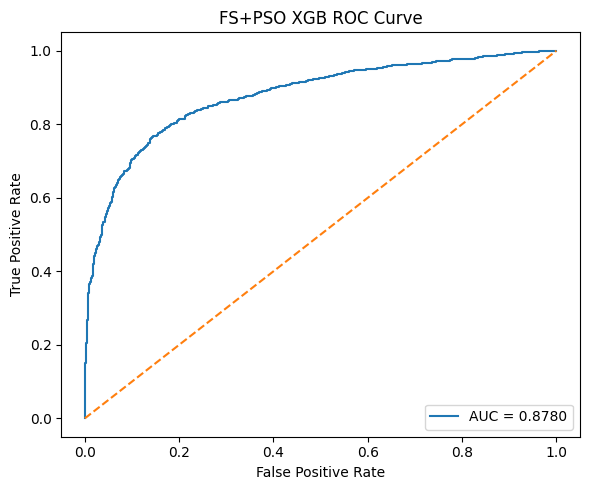

ROC kaydedildi: /content/drive/MyDrive/AUE_DR/Outputs/Plots/XGB_FS_PSO_OPT_ROC_20260122_003501.png


In [ ]:
# =========================
# 7) FINAL TRAIN (Train+Val) + TEST EVALUATION
# =========================

key_best = (
    best_params["n_estimators"],
    best_params["max_depth"],
    round(best_params["learning_rate"], 5),
    round(best_params["subsample"], 4),
    round(best_params["colsample_bytree"], 4),
)

best_it = xgb_cache.get(key_best, {}).get("best_iteration", None)
if best_it is not None:
    final_n_estimators = int(best_it) + 1
    print("\nFinal training n_estimators (best_iteration+1):", final_n_estimators)
else:
    final_n_estimators = best_params["n_estimators"]
    print("\nFinal training n_estimators (bounds):", final_n_estimators)

X_trainval = np.vstack([Xtr_fs, Xva_fs])
y_trainval = np.concatenate([y_train, y_val])

final_xgb = XGBClassifier(
    n_estimators=final_n_estimators,
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    min_child_weight=best_params["min_child_weight"],
    reg_lambda=best_params["reg_lambda"],

    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
    tree_method=TREE_METHOD
)

final_xgb.fit(X_trainval, y_trainval)

test_prob = final_xgb.predict_proba(Xte_fs)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

test_mf1, test_auc = macro_f1_auc(y_test, test_prob, thr=0.5)

xgb_cm = confusion_matrix(y_test, test_pred)

print("\nPSO-TUNED XGBoost (TEST)\n")
print(classification_report(y_test, test_pred, target_names=["DR_negatif", "DR_pozitif"], digits=4))
print("TEST Macro-F1:", round(test_mf1, 4))
print("TEST AUC     :", round(test_auc, 4))
print("CM:\n", xgb_cm)

cm_path = PLOT_DIR / f"XGB_FS_PSO_OPT_CM_{RUN_ID}.png"
roc_path = PLOT_DIR / f"XGB_FS_PSO_OPT_ROC_{RUN_ID}.png"
save_confusion_matrix(xgb_cm, ["DR_negatif","DR_pozitif"], cm_path, title="FS+PSO XGB Confusion Matrix")

save_roc_curve(y_test, test_prob, roc_path, title="FS+PSO XGB ROC Curve")
